# **Bloco 1: Capa**

## MVP do Sprint Análise de Dados e Boas Práticas

- **Aluno:** Diogo Reis Beltrão Lessa
- **Matrícula:** 4052025002548  
- **Curso:** Pós-Graduação em Ciência de Dados e Analytics - PUC-Rio

---

## Dataset

**Credit Card Customers (BankChurners)**  
Fonte: [Kaggle: sakshigoyal7/credit-card-customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

| Característica | Valor |
|---|---|
| Registros | `10.127` clientes |
| Variáveis originais | 23 (21 utilizáveis) |
| Variável-alvo | `Attrition_Flag` (Existing Customer / Attrited Customer) |


---

## Objetivo

Analisar o perfil e o comportamento de clientes de cartão de crédito para identificar os fatores mais associados ao **churn** (cancelamento do cartão), aplicando técnicas de análise exploratória de dados (EDA) e pré-processamento.

# Bloco 2: Definição do Problema

## 2.1 Descrição do Problema

O dataset **Credit Card Customers (BankChurners)**, disponível no Kaggle, simula o cenário de um banco que observa uma taxa de cancelamento de aproximadamente **`16%`** nos cartões de crédito. Segundo a descrição original do dataset, o contexto é o de um gerente bancário que precisa prever quais clientes vão cancelar seus cartões para poder atuar preventivamente na retenção.

A taxa de `~16%` é derivada da própria distribuição da variável-alvo no dataset: aproximadamente **`1.627` clientes classificados como "Attrited Customer"** em um total de **`10.127` registros**. Os demais `~8.500` clientes permanecem ativos ("Existing Customer").

O objetivo deste trabalho é identificar, por meio de **análise exploratória de dados (EDA) e pré-processamento**, quais características dos clientes estão mais associadas ao churn, preparando os dados para um futuro modelo preditivo de retenção. A etapa de modelagem não faz parte do escopo deste MVP.

## 2.2 Hipóteses do Problema

Com base no domínio de negócio e nas variáveis disponíveis, levantamos as seguintes hipóteses a serem investigadas e respondidas ao longo deste notebook:

**H1: Inatividade e churn**  
Clientes com mais meses de inatividade nos últimos 12 meses (`Months_Inactive_12_mon`) apresentam maior taxa de cancelamento do cartão.

**H2: Utilização do crédito e churn**  
Clientes com baixa taxa de utilização do limite de crédito (`Avg_Utilization_Ratio`) têm maior propensão ao churn, indicando desengajamento com o produto.

**H3: Número de produtos bancários e churn**  
Clientes com menor número de produtos contratados com o banco (`Total_Relationship_Count`) cancelam o cartão com maior frequência, sugerindo menor vínculo com a instituição.

**H4: Faixa de renda e churn**  
A faixa de renda do cliente (`Income_Category`) influencia a probabilidade de cancelamento - clientes de renda mais baixa podem ter maior pressão financeira para cancelar, enquanto clientes de renda alta podem buscar produtos mais vantajosos em outros bancos.

**H5: Redução de transações e churn**  
Clientes que reduziram sua contagem de transações do Q1 para o Q4 (`Total_Ct_Chng_Q4_Q1` com valores menores indicando queda) apresentam maior risco de cancelamento, revelando uma mudança comportamental que precede o churn.

## 2.3 Tipo de Problema

Trata-se de um problema de **classificação supervisionada binária**:

- **Variável-alvo:** `Attrition_Flag`
  - `"Existing Customer"` → cliente ativo (classe majoritária, `~84%`)
  - `"Attrited Customer"` → cliente que cancelou (classe minoritária, `~16%`)

O **escopo deste MVP** abrange exclusivamente as etapas de **Análise Exploratória de Dados (EDA)** e **Pré-Processamento**. A etapa de modelagem preditiva (treinamento e avaliação de classificadores) é um próximo passo natural, mas está fora do escopo atual.

O desbalanceamento de classes (`~84%/16%`) é uma característica relevante que será discutida ao longo do notebook e deverá ser tratada na etapa de modelagem futura.

## 2.4 Seleção de Dados

**Fonte:** Kaggle - [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers), publicado por sakshigoyal7.

**Dimensões:** `10.127` instâncias × `23` colunas originais (`20` utilizáveis após remoção de `CLIENTNUM` e das `2` colunas de saída do Naive Bayes inseridas pelo autor do dataset).

**Justificativa para a escolha deste dataset:**

- **Riqueza de variáveis:** mistura equilibrada de variáveis numéricas (`14`) e categóricas (`5`), exigindo diferentes estratégias de encoding e pré-processamento.
- **Missing values disfarçados:** a categoria `"Unknown"` presente em três colunas (`Education_Level`, `Marital_Status`, `Income_Category`) representa um caso realista de dado faltante implícito - comum em datasets de negócio.
- **Desbalanceamento de classes:** a proporção `~84%/16%` é típica de problemas de churn e exige atenção especial, sendo um excelente exercício de análise crítica.
- **Contexto de negócio claro:** o problema de retenção de clientes é relevante e bem delimitado, facilitando a formulação de hipóteses e a interpretação dos resultados.
- **Potencial para múltiplas técnicas:** o dataset é adequado para demonstrar normalização, padronização, encoding ordinal, One-Hot Encoding (OHE), detecção de outliers, transformação logarítmica e feature engineering.

## 2.5 Atributos do Dataset

O dataset original possui `23` colunas. Após remoção de `CLIENTNUM` (identificador sem valor preditivo) e das `2` últimas colunas (outputs do modelo Naive Bayes inseridos pelo autor), restam **`20` variáveis utilizáveis**:

| # | Variável | Tipo | Descrição |
|---|---|---|---|
| 1 | `Attrition_Flag` | Categórica (target) | Status do cliente: `"Existing Customer"` ou `"Attrited Customer"` |
| 2 | `Customer_Age` | Numérica (int) | Idade do cliente em anos |
| 3 | `Gender` | Categórica binária | Gênero: `M` ou `F` |
| 4 | `Dependent_count` | Numérica (int) | Número de dependentes (0-5) |
| 5 | `Education_Level` | Categórica ordinal | Escolaridade: `Uneducated`, `High School`, `College`, `Graduate`, `Post-Graduate`, `Doctorate`, **Unknown** |
| 6 | `Marital_Status` | Categórica nominal | Estado civil: `Married`, `Single`, `Divorced`, **Unknown** |
| 7 | `Income_Category` | Categórica ordinal | Faixa de renda: `Less than $40K`, `$40K - $60K`, `$60K - $80K`, `$80K - $120K`, `$120K +`, **Unknown** |
| 8 | `Card_Category` | Categórica ordinal | Tipo de cartão: `Blue`, `Silver`, `Gold`, `Platinum` |
| 9 | `Months_on_book` | Numérica (int) | Tempo como cliente do banco (em meses) |
| 10 | `Total_Relationship_Count` | Numérica (int) | Total de produtos contratados com o banco (1-6) |
| 11 | `Months_Inactive_12_mon` | Numérica (int) | Meses inativos nos últimos 12 meses |
| 12 | `Contacts_Count_12_mon` | Numérica (int) | Número de contatos com o banco nos últimos 12 meses |
| 13 | `Credit_Limit` | Numérica (float) | Limite de crédito do cartão |
| 14 | `Total_Revolving_Bal` | Numérica (int) | Saldo rotativo total (quanto o cliente deve no cartão) |
| 15 | `Avg_Open_To_Buy` | Numérica (float) | Limite disponível médio (Credit_Limit − Total_Revolving_Bal) |
| 16 | `Total_Amt_Chng_Q4_Q1` | Numérica (float) | Variação do valor transacionado entre Q4 e Q1 |
| 17 | `Total_Trans_Amt` | Numérica (int) | Valor total transacionado no período |
| 18 | `Total_Trans_Ct` | Numérica (int) | Contagem total de transações no período |
| 19 | `Total_Ct_Chng_Q4_Q1` | Numérica (float) | Variação da contagem de transações entre Q4 e Q1 |
| 20 | `Avg_Utilization_Ratio` | Numérica (float) | Taxa média de utilização do crédito (0.0-1.0) |



> **Nota sobre "Unknown":** As colunas `Education_Level`, `Marital_Status` e `Income_Category` contêm a categoria `"Unknown"` como proxy de valores faltantes. As quantidades exatas serão calculadas a partir do CSV na etapa de EDA (Bloco 4). Serão avaliadas três estratégias de tratamento no pré-processamento (Bloco 5).

# Bloco 3: Importações e Carga de Dados

## 3.1 Importação das Bibliotecas Necessárias

Esta seção centraliza todos os imports do projeto e o carregamento do dataset. Manter os imports em um único bloco é uma boa prática que facilita a leitura, evita dependências ocultas entre células e simplifica a adaptação do notebook para outros ambientes.

As bibliotecas utilizadas cobrem:
- **Manipulação de dados:** `pandas`, `numpy`
- **Visualização:** `matplotlib`, `seaborn`
- **Pré-processamento:** `scikit-learn` (scalers, encoders, split)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de visualização
sns.set_theme(style='whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [3]:
# Carregamento do dataset a partir do repositório GitHub
url = 'https://raw.githubusercontent.com/diogorblessa/mvp-credit-card-churn/main/data/BankChurners.csv'
df = pd.read_csv(url)

# Verificar duplicatas
total_duplicatas = df.duplicated().sum()
print(f"\nLinhas duplicadas: {total_duplicatas}")

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()




Linhas duplicadas: 0
Dataset carregado: 10127 linhas x 23 colunas


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3.2 Limpeza Inicial

Antes de iniciar qualquer análise, removemos as colunas que não devem fazer parte do dataset utilizável:

1. **`CLIENTNUM`**: é apenas um número de identificação do cliente, como um número de matrícula. Ele não diz nada sobre o comportamento ou perfil da pessoa. Se mantivermos essa coluna, algoritmos de machine learning podem tratá-la como uma variável numérica comum e encontrar padrões falsos, como associar determinadas faixas de IDs a churn por pura coincidência. Isso prejudicaria a capacidade do modelo de funcionar com dados novos.

2. **Colunas `Naive_Bayes_Classifier_*` (as 2 últimas)**: são outputs de um modelo que foram inseridas pelo autor do dataset e contêm o resultado de um modelo já treinado para prever churn. Ou seja, essas colunas já carregam a resposta que queremos descobrir.

Após a remoção, verificamos a presença de **linhas duplicadas**, que poderiam distorcer estatísticas e pesos em modelagem futura.

In [4]:
# Remover CLIENTNUM (identificador sem valor preditivo)
df = df.drop(columns=['CLIENTNUM'])

# Remover as 2 últimas colunas (outputs do Naive Bayes inseridos pelo autor do dataset)
colunas_naive_bayes = [col for col in df.columns if col.startswith('Naive_Bayes_Classifier_')]
print(f"Colunas Naive Bayes removidas: {colunas_naive_bayes}")
df = df.drop(columns=colunas_naive_bayes)

# Verificar duplicatas
total_duplicatas = df.duplicated().sum()
print(f"\nLinhas duplicadas: {total_duplicatas}")

# Shape final
print(f"\nShape após limpeza: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Colunas restantes: {list(df.columns)}")
df.head()


Colunas Naive Bayes removidas: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Linhas duplicadas: 0

Shape após limpeza: 10127 linhas × 20 colunas
Colunas restantes: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# Bloco 4: Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados (EDA) é a etapa em que investigamos a estrutura, distribuição e relacionamentos do dataset antes de qualquer modelagem. Seu objetivo é compreender o que os dados dizem, identificar padrões, anomalias e possíveis problemas de qualidade, e gerar hipóteses que serão testadas ao longo do notebook.

Neste bloco, a EDA está organizada nas seguintes subseções:
1. **Total e tipo das instâncias**, quantidade de registros, tipos de variáveis e distribuição do target
2. **Estatísticas descritivas**, média, desvio padrão, quartis e escala das variáveis numéricas
3. **Histogramas**, distribuição de frequência das variáveis numéricas
4. **Distribuição das variáveis categóricas**, frequência de cada categoria
5. **Boxplots por grupo**, comparação entre clientes ativos e cancelados
6. **Análises bivariadas**, cruzamento das categóricas com o target
7. **Matriz de correlação**, relacionamentos entre variáveis numéricas
8. **Valores nulos e "Unknown"**, identificação de dados faltantes explícitos e implícitos

Além disso, iremos buscar respostas para as seguintes perguntas:
1. **Qual é a distribuição do churn?** Qual percentual de clientes cancelou? Há desbalanceamento?
2. **Idade e churn:** Existe uma faixa etária com maior taxa de cancelamento?
3. **Gênero e churn:** A proporção de churn difere entre homens e mulheres?
4. **Educação e churn:** Clientes com maior escolaridade cancelam mais ou menos?
5. **Renda e churn:** Há relação entre faixa de renda e probabilidade de cancelamento?
6. **Categoria do cartão:** Clientes Gold/Platinum cancelam mais ou menos que Blue/Silver?
7. **Inatividade:** Quantos meses inativos antes do cancelamento? A inatividade é um preditor forte?
8. **Transações:** Clientes que cancelam fazem menos transações? Há diferença no valor médio?
9. **Utilização do crédito:** Clientes com baixa utilização cancelam mais?
10. **Correlações:** Quais variáveis numéricas têm alta correlação entre si? Existe multicolinearidade (ex: Credit_Limit vs Avg_Open_To_Buy)?

## 4.1 Total e Tipo das Instâncias

Antes de analisar os dados, é fundamental entender sua estrutura: quantas instâncias (linhas) e variáveis (colunas) temos, quais são os tipos de cada variável e se existe algum problema óbvio de tipo ou formato.

In [5]:
# Total de instâncias e estrutura geral
print(f"Total de instâncias: {len(df)}")
print(f"Total de colunas: {df.shape[1]}")
print()

# Contagem por tipo
total_numericas = df.select_dtypes(include='number').shape[1]
total_categoricas = df.select_dtypes(include='object').shape[1]
print(f"Variáveis numéricas: {total_numericas}")
print(f"Variáveis categóricas (incl. target): {total_categoricas}")
print()

# Tipos de cada coluna
print("Tipos de dados por coluna:")
print(df.dtypes)
print()

# Visão geral completa
df.info()

Total de instâncias: 10127
Total de colunas: 20

Variáveis numéricas: 14
Variáveis categóricas (incl. target): 6

Tipos de dados por coluna:
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column    

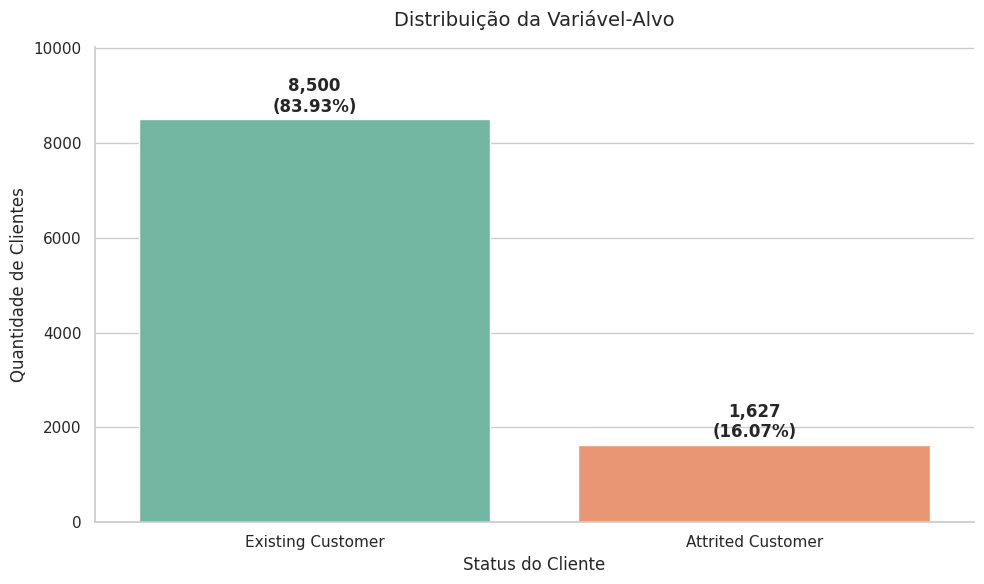

In [6]:
# Distribuição da variável-alvo (Attrition_Flag)
fig, ax = plt.subplots(figsize=(10, 6))

ordem_target = ['Existing Customer', 'Attrited Customer']
sns.countplot(x='Attrition_Flag', data=df, palette='Set2', ax=ax,
              order=ordem_target)

# Anotar percentuais e contagens sobre cada barra
total = len(df)
for p in ax.patches:
    valor = int(p.get_height())
    percentual = valor / total * 100
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 80,
        f'{valor:,}\n({percentual:.2f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('Distribuição da Variável-Alvo', fontsize=14, pad=15)
ax.set_xlabel('Status do Cliente', fontsize=12)
ax.set_ylabel('Quantidade de Clientes', fontsize=12)
ax.set_ylim(0, df['Attrition_Flag'].value_counts().max() * 1.18)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Após a limpeza inicial realizada no Bloco 3, o dataset possui `10.127` instâncias (clientes) e `20` variáveis utilizáveis: `14` numéricas e `6` categóricas (incluindo o target `Attrition_Flag`).

O gráfico mostra que o dataset tem muito mais clientes ativos do que cancelados: **`8.500` clientes ativos (`83,93%`)** contra **`1.627` que cancelaram o cartão (`16,07%`)**. Essa diferença de proporção, cerca de 5 clientes ativos para cada 1 que cancelou, é chamada de **desbalanceamento entre classes** e é muito comum em problemas de churn.

Isso tem uma consequência prática importante: ao cruzar a variável-alvo com outras variáveis nas próximas análises, precisamos sempre comparar **proporções** (taxas percentuais) em vez de quantidades absolutas. Por exemplo, dizer que "500 clientes ativos têm renda alta" não significa muito se não compararmos com a proporção dos que cancelaram com a mesma renda, do contrário, o grupo maior vai sempre parecer mais relevante só por ser maior.

Na etapa de modelagem futura (fora do escopo deste MVP), esse desbalanceamento também precisará ser tratado para que o modelo não aprenda simplesmente a dizer que todo cliente é ativo, o que daria `84%` de acerto mas não identificaria nenhum cancelamento, tornando o modelo inútil na prática.

## 4.2 Estatísticas Descritivas

As estatísticas descritivas resumem cada variável numérica em poucos números. O método `df.describe()` do pandas calcula automaticamente:
- **Média (`mean`)**: valor central da distribuição
- **Desvio padrão (`std`)**: quanto os valores se afastam da média
- **Mínimo, máximo e quartis (`25%`, `50%`, `75%`)**: amplitude e distribuição dos dados

Na tabela abaixo, observe especialmente a relação entre média e desvio padrão: quando o desvio padrão é parecido com (ou maior que) a própria média, os dados estão muito espalhados e a média sozinha não resume bem a variável.

In [7]:
# Resumo estatístico completo das variáveis numéricas
df.describe().round(2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


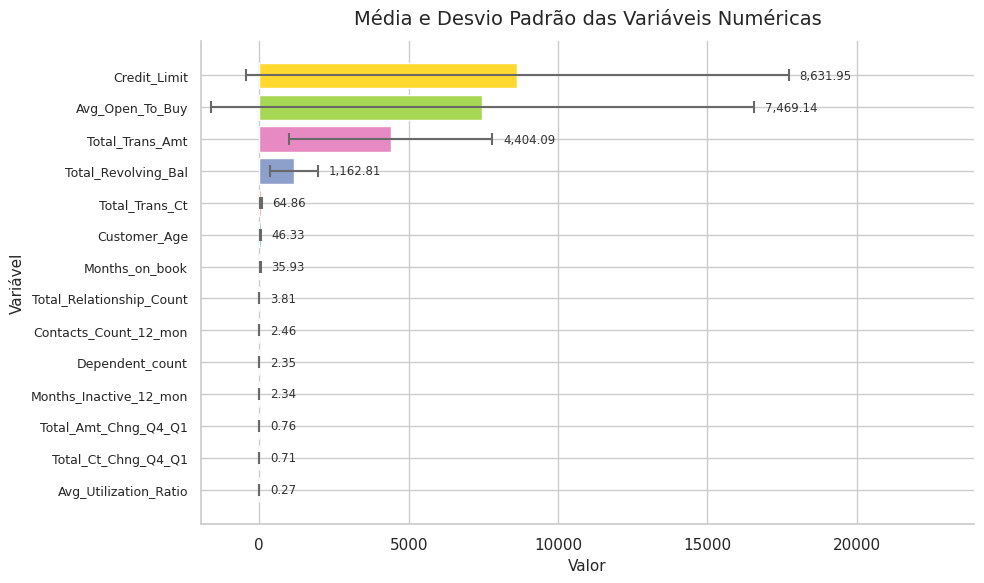

In [8]:
# Gráfico de barras horizontais: média ± desvio padrão das variáveis numéricas
colunas_num = df.select_dtypes(include='number').columns.tolist()
medias_vals = df[colunas_num].mean()
desvios_vals = df[colunas_num].std()

# Ordenar por média crescente para melhor leitura
ordem = medias_vals.sort_values().index

fig, ax = plt.subplots(figsize=(10, 6))
cores = sns.color_palette('Set2', n_colors=len(ordem))

ax.barh(
    range(len(ordem)),
    medias_vals[ordem],
    xerr=desvios_vals[ordem],
    color=cores,
    edgecolor='white',
    capsize=4,
    error_kw={'elinewidth': 1.5, 'ecolor': 'dimgray', 'capthick': 1.5}
)

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem, fontsize=9)
ax.set_title('Média e Desvio Padrão das Variáveis Numéricas', fontsize=14, pad=12)
ax.set_xlabel('Valor', fontsize=11)
ax.set_ylabel('Variável', fontsize=11)

# Anotação dos valores de média posicionados após o bigode de erro
x_max = (medias_vals[ordem] + desvios_vals[ordem]).max()
folga = x_max * 0.02
for i, col in enumerate(ordem):
    x_anotacao = medias_vals[col] + desvios_vals[col] + folga
    ax.text(
        x_anotacao, i,
        f'{medias_vals[col]:,.2f}',
        va='center', ha='left', fontsize=8.5, color='#333333'
    )

x_min_dados = (medias_vals[ordem] - desvios_vals[ordem]).min()
margem_esq = abs(x_min_dados) * 0.20 if x_min_dados < 0 else 0
ax.set_xlim(x_min_dados - margem_esq, x_max * 1.35)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

O gráfico apresenta a média (barra) e o desvio padrão (intervalo de erro) de cada variável. As variáveis `Credit_Limit` e `Avg_Open_To_Buy` dominam o eixo por operar na casa dos milhares, enquanto `Avg_Utilization_Ratio` (`0,27`) e `Total_Ct_Chng_Q4_Q1` (`0,71`) ficam praticamente invisíveis na mesma escala. Essa diferença de escala será tratada com normalização e padronização nas Seções 5.8 e 5.9.

A tabela `describe()` complementa o gráfico com informações que ele não mostra: mínimo, máximo e quartis. Os principais achados:

**Assimetria: quando a média não resume bem os dados**
Os quartis revelam quando a média é enganosa. Em `Credit_Limit`, a **mediana** (valor que divide os dados ao meio) é `R$ 4.549,00`, mas a média chega a `R$ 8.631,95`, puxada por poucos clientes com limites muito altos (máximo de `R$ 34.516,00`). O desvio padrão de `R$ 9.088,78` é maior que a própria média, confirmando essa grande dispersão. O mesmo padrão aparece em `Total_Trans_Amt`: mediana de `R$ 3.899,00` contra média de `R$ 4.404,09`. Quando a média é bem maior que a mediana, os dados têm **assimetria à direita**, pois a cauda dos valores altos puxa a média para cima. Os histogramas da Seção 4.3 mostrarão essa forma.

**Utilização do crédito (Avg_Utilization_Ratio):**
O mínimo é `0,00` e o máximo é `1,00`, mas a mediana é apenas `0,18`. Isso significa que mais de `50%` dos clientes utilizam menos de `18%` do limite disponível. O 3.º quartil é `0,50`, ou seja, `75%` dos clientes não chegam nem à metade do limite. Essa baixa utilização na maioria da base é um sinal inicial relacionado à Hipótese H2, que investiga se existe relação entre taxa de utilização do crédito e churn.

**Inatividade (Months_Inactive_12_mon):**
O 1.º quartil e a mediana são ambos `2`, o que significa que mais de `50%` dos clientes ficaram inativos em pelo menos `2` meses nos últimos `12`. O máximo é `6` meses. Esse dado já antecipa um sinal a ser investigado na Hipótese H1, que investiga se clientes inativos têm maior taxa de cancelamento.

**Saldo rotativo (Total_Revolving_Bal)**
O mínimo é `0`: existem clientes que pagam a fatura integralmente todo mês e nunca acumulam saldo. A mediana é `1.276` e o máximo é `2.517`, com `75%` dos clientes abaixo de `1.784`. A maior parte da base carrega algum saldo, mas há variação considerável.

**Transações (Total_Trans_Ct):**
A contagem de transações varia de `10` a `139`, com mediana de `67`. O intervalo interquartil vai de `45` a `81`: a metade central dos clientes fez entre `45` e `81` transações no período. Essa amplitude será importante para avaliar a Hipótese H5, que investiga se a queda no volume de transações está associada ao churn.

**Variáveis com distribuição mais uniforme**
`Customer_Age` (de `26` a `73` anos, mediana `46`, desvio padrão `8,02`) e `Months_on_book` (de `13` a `56` meses, mediana `36`, desvio padrão `7,99`) têm desvios pequenos em relação às médias, indicando que os clientes são relativamente similares nessas dimensões.

## 4.3 Histogramas das Variáveis Numéricas

Os histogramas revelam a **forma da distribuição** de cada variável numérica, informação que as estatísticas descritivas da Seção 4.2 apenas sugeriam. Enquanto média, mediana e desvio padrão descrevem propriedades pontuais, o histograma mostra visualmente se os valores estão concentrados em uma faixa estreita, se a distribuição tem um pico principal ou dois grupos separados, e se há valores extremos afastados do restante.

Nas variáveis contínuas, uma linha suave aparece sobre as barras do histograma. Ela se chama curva KDE e serve apenas para mostrar o contorno geral da distribuição de forma mais fluida, facilitando a leitura quando as barras são estreitas. Para variáveis com poucos valores inteiros possíveis, como `Dependent_count` e `Months_Inactive_12_mon`, essa linha é omitida porque criaria ondulações artificiais que não existem nos dados.

Cada histograma também exibe duas linhas verticais: a linha sólida vermelha indica a média e a linha tracejada azul indica a mediana. Quando as duas estão próximas, a distribuição é mais simétrica. Quando estão afastadas, como já sinalizavam os dados da Seção 4.2 para `Credit_Limit` e `Avg_Open_To_Buy`, isso confirma a assimetria daquelas variáveis.

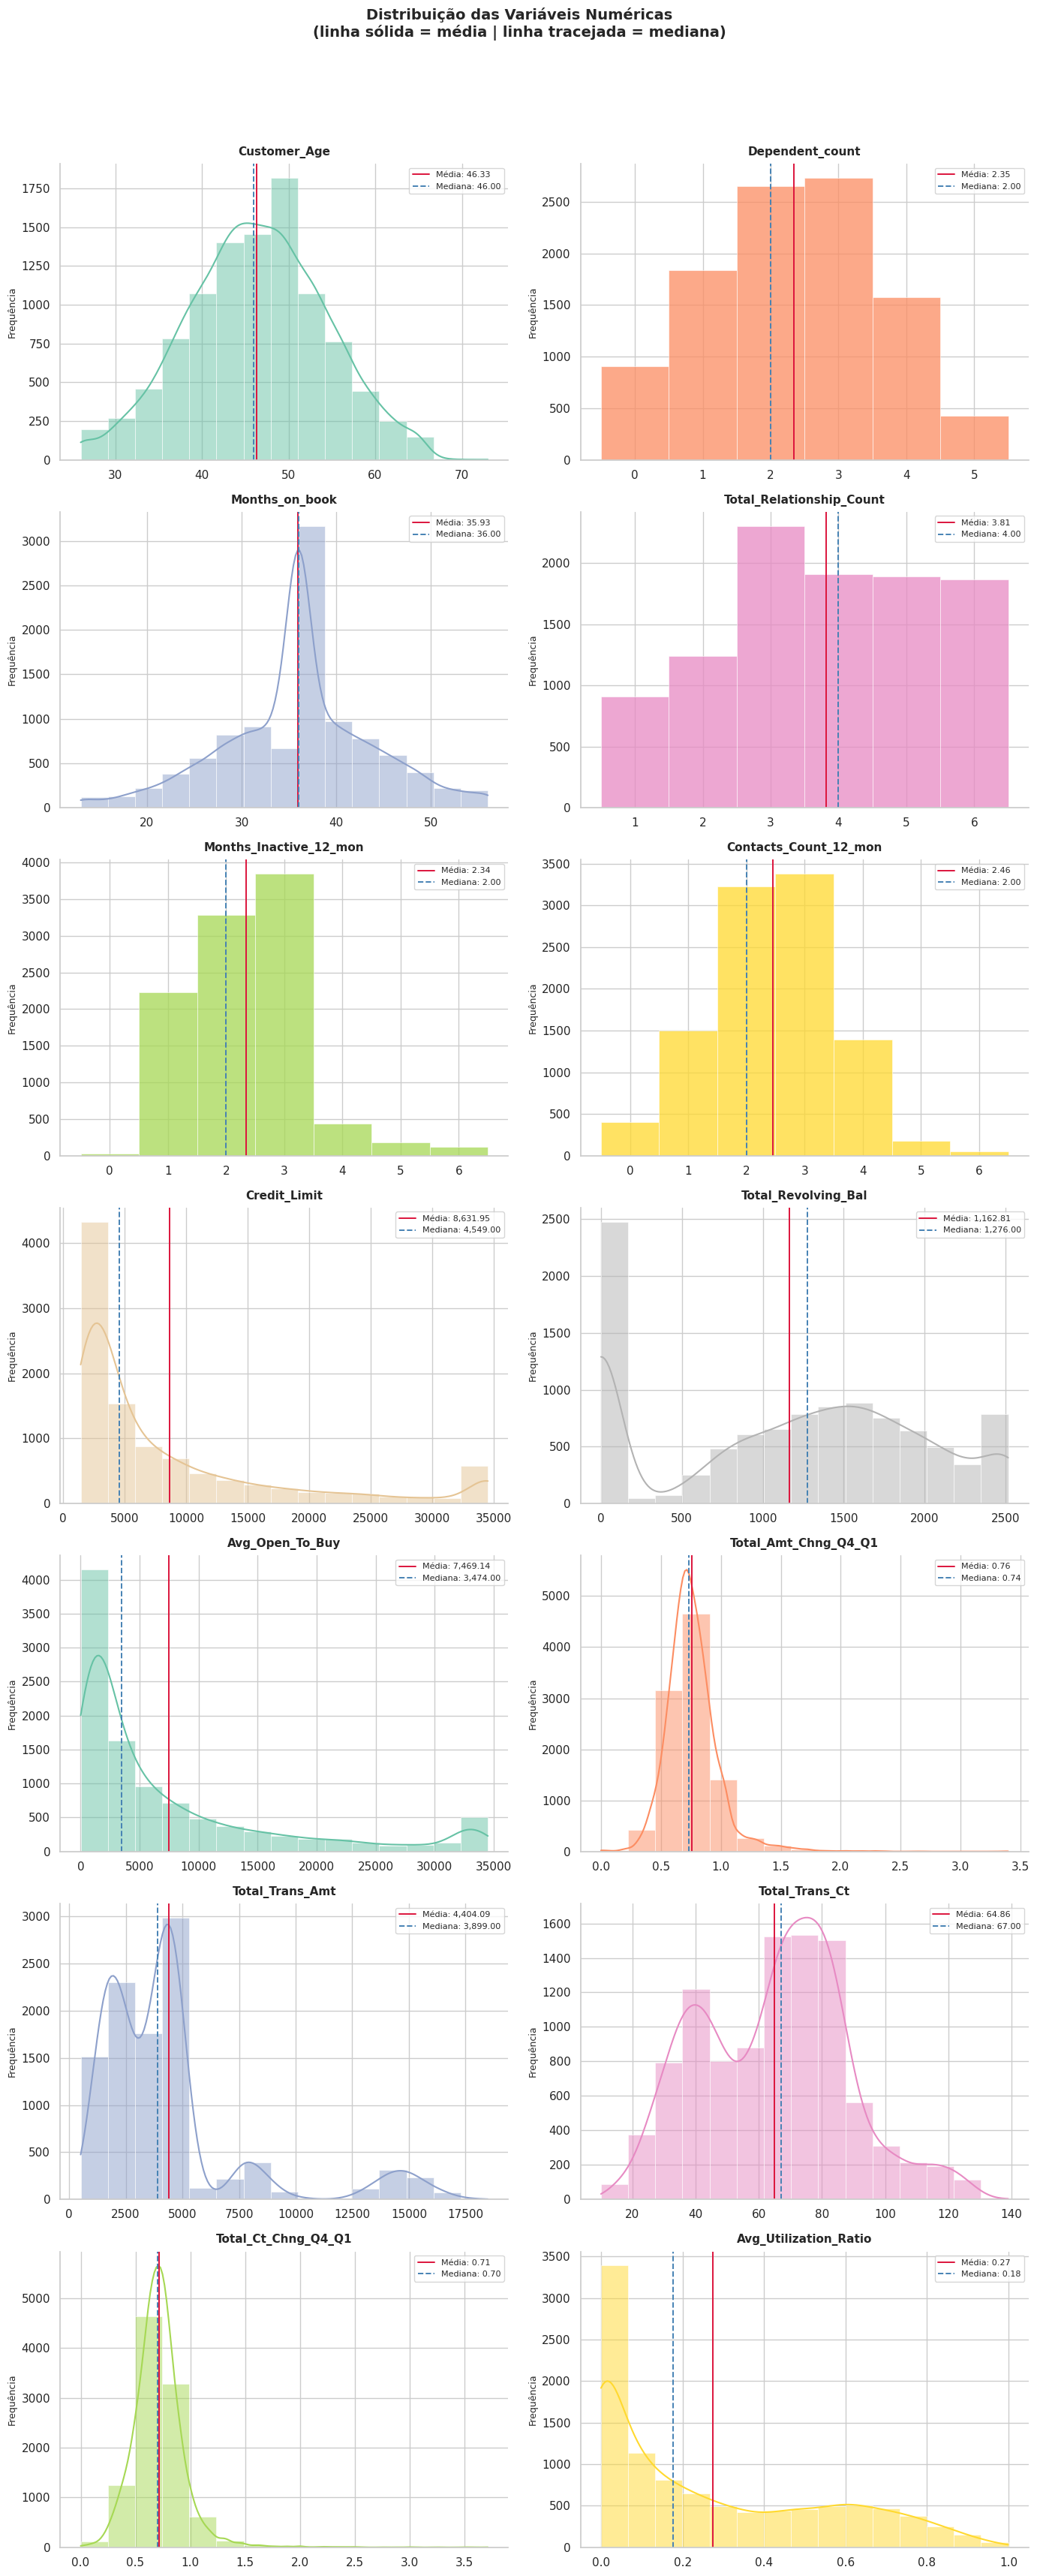

In [34]:
# Histogramas de todas as variáveis numéricas com curva KDE
colunas_num = df.select_dtypes(include='number').columns.tolist()

# Variáveis discretas: poucas categorias inteiras — KDE cria ondulações artificiais
colunas_discretas = {'Dependent_count', 'Total_Relationship_Count',
                     'Months_Inactive_12_mon', 'Contacts_Count_12_mon'}

num_colunas = 2
num_linhas  = (len(colunas_num) + num_colunas - 1) // num_colunas  # 7 linhas para 14 variáveis

figura, eixos = plt.subplots(num_linhas, num_colunas, figsize=(14, 35))
eixos = eixos.flatten()

cores = sns.color_palette('Set2', n_colors=len(colunas_num))

for indice, nome_coluna in enumerate(colunas_num):
    media             = df[nome_coluna].mean()
    mediana           = df[nome_coluna].median()
    variavel_discreta = nome_coluna in colunas_discretas

    if variavel_discreta:
        # Variáveis discretas: sem KDE, barras centradas nos valores inteiros
        sns.histplot(df[nome_coluna], kde=False, ax=eixos[indice], color=cores[indice],
                     discrete=True, edgecolor='white', linewidth=0.4)
    else:
        sns.histplot(df[nome_coluna], kde=True, ax=eixos[indice], color=cores[indice], bins=15,
                     edgecolor='white', linewidth=0.4)

    eixos[indice].set_title(nome_coluna, fontsize=11, fontweight='bold', pad=8)
    eixos[indice].set_xlabel('')
    eixos[indice].set_ylabel('Frequência', fontsize=9)

    # Linhas de referência: média (sólida) e mediana (tracejada)
    eixos[indice].axvline(media,   color='crimson',   linestyle='-',  linewidth=1.4,
                          label=f'Média: {media:,.2f}')
    eixos[indice].axvline(mediana, color='steelblue', linestyle='--', linewidth=1.4,
                          label=f'Mediana: {mediana:,.2f}')
    eixos[indice].legend(fontsize=8, loc='upper right')

# Remover eixos extras se o número de variáveis for ímpar
for indice_extra in range(len(colunas_num), len(eixos)):
    figura.delaxes(eixos[indice_extra])

plt.suptitle('Distribuição das Variáveis Numéricas\n(linha sólida = média | linha tracejada = mediana)',
             fontsize=14, fontweight='bold')
sns.despine(fig=figura)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [38]:
# Estatísticas de suporte para a análise dos histogramas
# Todos os números citados na célula de análise abaixo são rastreáveis a esta célula

print("=" * 55)
print("VARIÁVEIS DISCRETAS: contagem por valor")
print("=" * 55)
colunas_discretas_lista = [
    'Dependent_count', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon'
]
for nome_coluna in colunas_discretas_lista:
        print(df[nome_coluna].value_counts().sort_index().to_string())

print("\n" + "=" * 55)
print("VARIÁVEIS CONTÍNUAS: percentis e extremos")
print("=" * 55)
colunas_continuas = [
    'Customer_Age', 'Months_on_book', 'Credit_Limit',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Ct_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Avg_Utilization_Ratio'
]
print(df[colunas_continuas].describe().loc[
    ['min', '25%', '50%', '75%', 'max', 'mean']
].round(2).to_string())

print("\n" + "=" * 55)
print("TOTAL_REVOLVING_BAL: destaques")
print("=" * 55)
saldo_zero          = (df['Total_Revolving_Bal'] == 0).sum()
percentual_zero     = saldo_zero / len(df) * 100
valor_maximo        = int(df['Total_Revolving_Bal'].max())
contagem_val_max    = (df['Total_Revolving_Bal'] == valor_maximo).sum()
print(f"Clientes com saldo zero (pagam fatura integral): {saldo_zero} ({percentual_zero:.1f}%)")
print(f"Clientes no valor máximo (R${valor_maximo:,}): {contagem_val_max}")


VARIÁVEIS DISCRETAS: contagem por valor
Dependent_count
0     904
1    1838
2    2655
3    2732
4    1574
5     424
Total_Relationship_Count
1     910
2    1243
3    2305
4    1912
5    1891
6    1866
Months_Inactive_12_mon
0      29
1    2233
2    3282
3    3846
4     435
5     178
6     124
Contacts_Count_12_mon
0     399
1    1499
2    3227
3    3380
4    1392
5     176
6      54

VARIÁVEIS CONTÍNUAS: percentis e extremos
      Customer_Age  Months_on_book  Credit_Limit  Avg_Open_To_Buy  Total_Amt_Chng_Q4_Q1  Total_Ct_Chng_Q4_Q1  Total_Trans_Amt  Total_Trans_Ct  Avg_Utilization_Ratio
min          26.00           13.00       1438.30             3.00                  0.00                 0.00           510.00           10.00                   0.00
25%          41.00           31.00       2555.00          1324.50                  0.63                 0.58          2155.50           45.00                   0.02
50%          46.00           36.00       4549.00          3474.00           

Os histogramas mostram como os valores de cada variável se distribuem entre os `10.127` clientes. A seguir, os principais padrões observados:

**Variáveis com distribuição próxima do normal (formato de sino):**
- **`Customer_Age`**: a maioria dos clientes tem entre `41` e `52` anos, com pico em torno dos `46`. Poucos clientes têm menos de `30` ou mais de `65` anos. A distribuição é bastante simétrica.
- **`Months_on_book`**: a maioria está entre `31` e `40` meses (cerca de `3` anos de relacionamento com o banco). Valores extremos, clientes muito novos (menos de `20` meses) ou muito antigos (mais de `50` meses), são menos comuns.

**Variáveis discretas:**
- **`Dependent_count`**: a maioria dos clientes tem `2` ou `3` dependentes. Valores extremos (`0` ou `5`) são raros.
- **`Total_Relationship_Count`**: a maioria dos clientes possui `3`, `4` ou `5` produtos contratados com o banco. Ter apenas `1` produto é incomum.
- **`Months_Inactive_12_mon`**: o valor mais comum é `2` meses de inatividade no último ano. Poucas pessoas ficaram completamente ativas (`0` meses) ou muito inativas (`5` a `6` meses).
- **`Contacts_Count_12_mon`**: a maioria dos clientes entrou em contato com o banco `2` ou `3` vezes no ano. Valores de `0` ou acima de `4` são menos frequentes.

**Variáveis com concentração nos valores menores e cauda longa à direita:**
- **`Credit_Limit`**: a maioria dos clientes tem um limite de crédito baixo (próximo ao mínimo de `~R$1.400`). Poucos têm limites muito altos (acima de `R$20.000`), mas esses valores puxam a média para cima, por isso a média (`R$8.631`) fica bem acima da mediana (`R$4.549`). Essa diferença grande entre média e mediana é um sinal claro de que a distribuição não é simétrica.
- **`Avg_Open_To_Buy`**: apresenta o mesmo padrão de `Credit_Limit`, o que faz sentido, pois essa variável representa o limite disponível (quanto ainda pode ser gasto).

**`Total_Revolving_Bal`, dois picos extremos:**
A primeira barra (próxima a zero) é bem mais alta que as demais: cerca de `24%` dos clientes não carregam saldo devedor no cartão, ou seja, pagam a fatura integral todo mês. A partir daí, a frequência cresce gradualmente até um pico em torno de `R$1.300` a `R$1.700`. Chama atenção também um segundo pico isolado no valor máximo (`R$2.517`), onde `508` clientes se concentram. Isso sugere um teto real para a variável: o banco ou o produto limita o saldo rotativo a esse valor, e uma parcela dos clientes opera constantemente no limite.

**`Total_Amt_Chng_Q4_Q1` e `Total_Ct_Chng_Q4_Q1`, variações de um trimestre para o outro:**
Ambas estão concentradas entre `0,5` e `1,0`, indicando que a maioria dos clientes manteve um padrão de gastos e transações relativamente estável entre os dois trimestres. A presença de poucos valores acima de `2,0` representa clientes com variações muito atípicas.

**`Total_Trans_Amt` e `Total_Trans_Ct`, dois perfis de uso:**
Nesses dois histogramas é possível enxergar dois grupos de clientes: um que usa o cartão com pouca frequência e valores baixos, e outro que usa com mais intensidade. Esse comportamento será importante para investigar a hipótese H5, que investiga se a queda nas transações está ligada ao churn.

**`Avg_Utilization_Ratio`, muitos clientes quase não usam o crédito:**
A primeira barra é muito mais alta que as demais, mostrando que grande parte dos clientes usa muito pouco do limite disponível (próximo de `0%`). Um segundo grupo usa em torno de `20%` a `50%` do limite. Essa divisão reforça a hipótese H2, que investiga se baixa utilização do crédito está associada ao cancelamento do cartão.

## 4.4 Distribuição das Variáveis Categóricas

Enquanto os histogramas da Seção 4.3 mostraram como os valores numéricos se distribuem, as variáveis categóricas precisam de uma abordagem diferente: basta contar quantos clientes estão em cada categoria. O gráfico de contagem (`countplot`) é a ferramenta ideal para isso.

O dataset possui `5` variáveis categóricas: `Gender`, `Education_Level`, `Marital_Status`, `Income_Category` e `Card_Category`. Dessas, `3` (`Education_Level`, `Marital_Status` e `Income_Category`) contêm a categoria `"Unknown"`, que representa registros onde o cliente não informou a resposta. Esse valor age como um substituto para dados ausentes, e avaliar o peso de cada um é essencial para decidir como tratá-los no pré-processamento (Bloco 5).

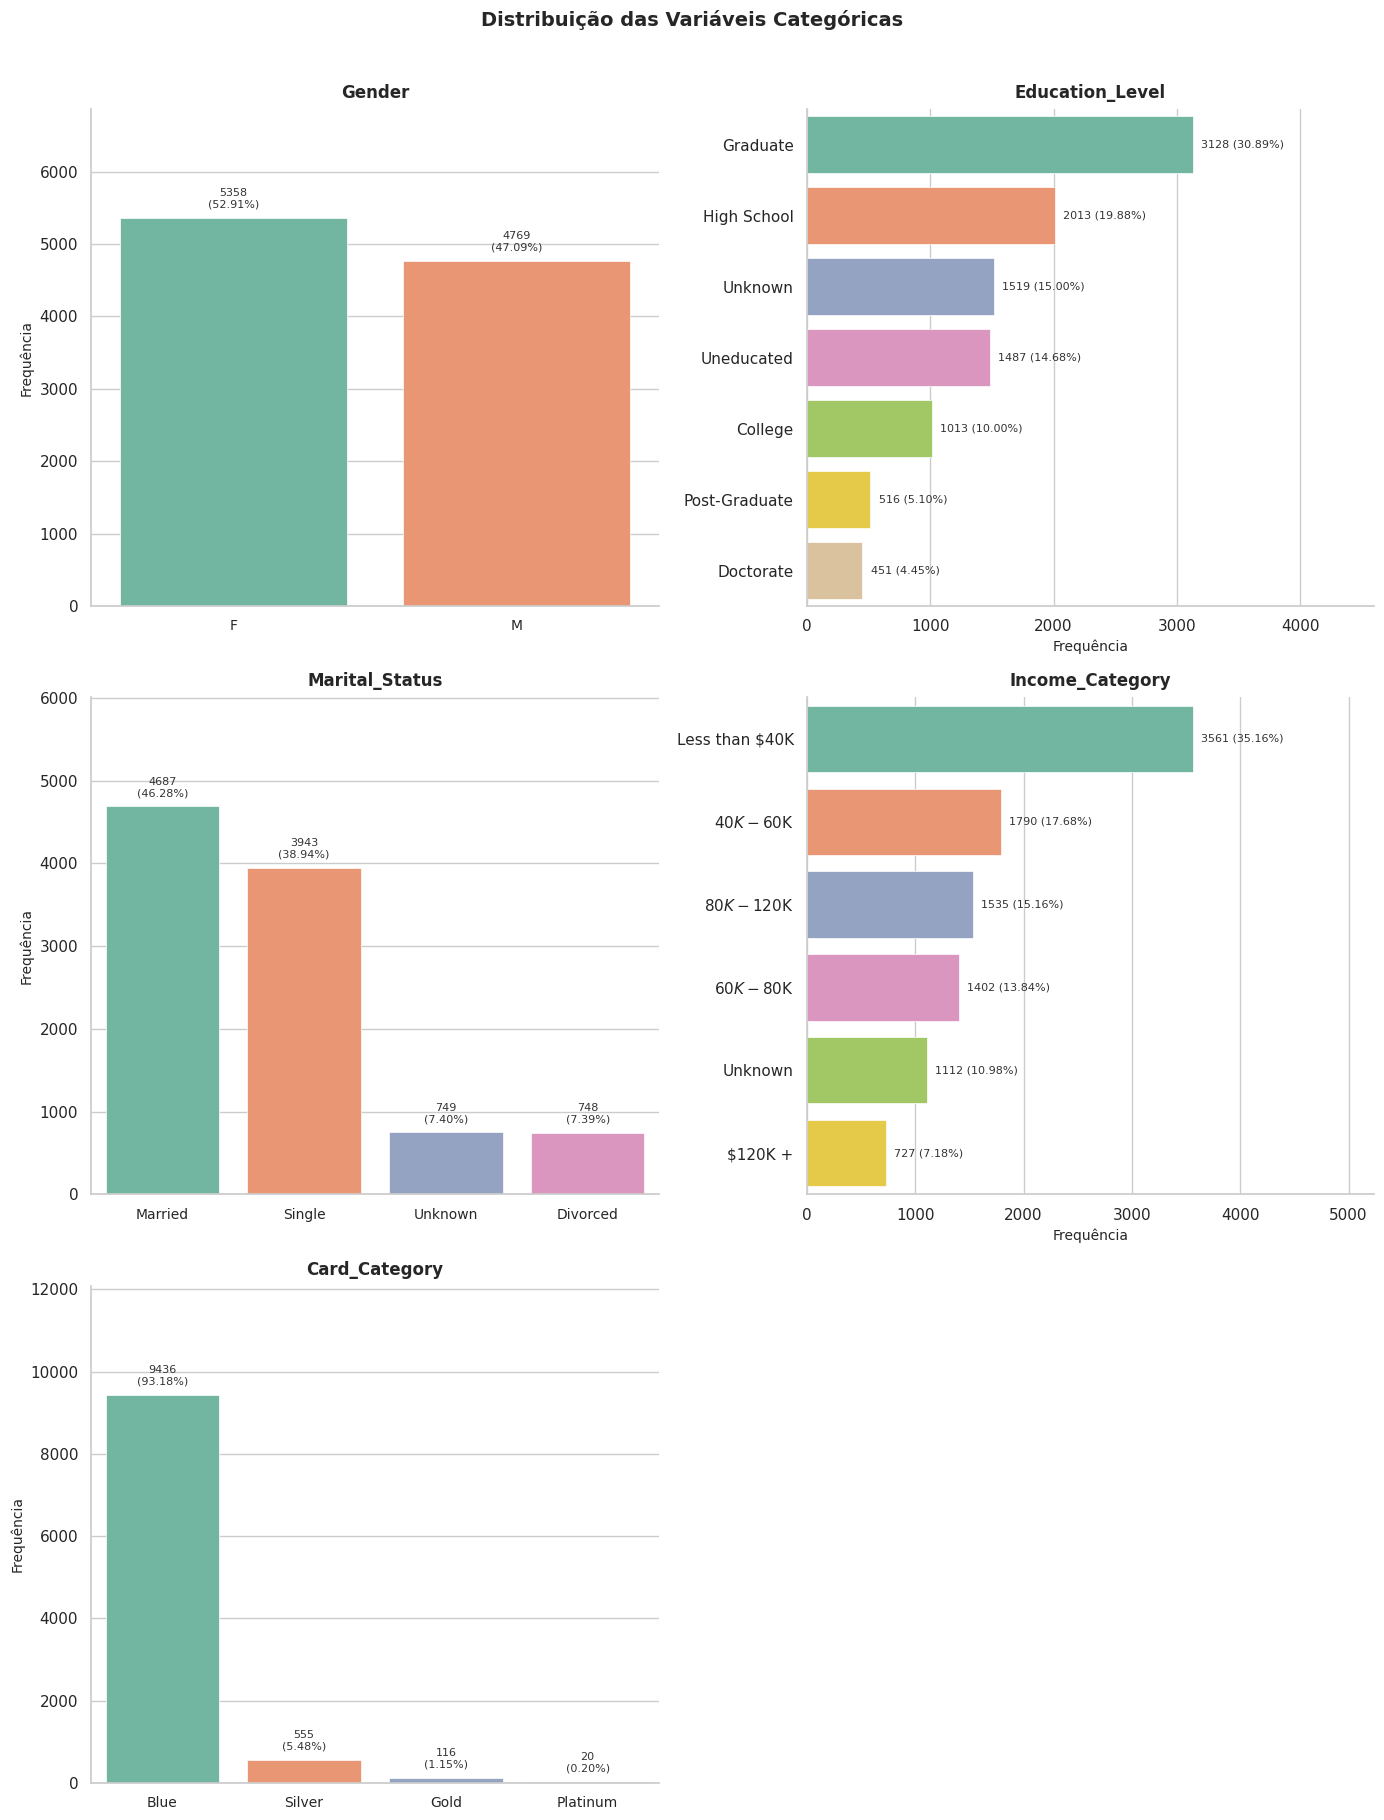

In [40]:
# Countplots das variáveis categóricas

categoricas = ['Gender', 'Education_Level', 'Marital_Status',
               'Income_Category', 'Card_Category']

# Variáveis com labels longos usam barras horizontais para evitar rotação de texto
horizontais = {'Income_Category', 'Education_Level'}

figura, eixos = plt.subplots(3, 2, figsize=(14, 18))
eixos = eixos.flatten()
total = len(df)

for indice, nome_coluna in enumerate(categoricas):
    # Ordem decrescente de frequência
    ordem = df[nome_coluna].value_counts().index.tolist()

    if nome_coluna in horizontais:
        # Gráfico horizontal: labels no eixo y, sem necessidade de rotação
        sns.countplot(data=df, y=nome_coluna, ax=eixos[indice], palette='Set2', order=ordem,
                      edgecolor='white', linewidth=0.5)
        eixos[indice].set_xlabel('Frequência', fontsize=10)
        eixos[indice].set_ylabel('')

        limite_direito = eixos[indice].get_xlim()[1]

        for barra in eixos[indice].patches:
            largura = barra.get_width()
            if largura > 0:
                percentual = largura / total * 100
                eixos[indice].text(
                    largura + limite_direito * 0.02,
                    barra.get_y() + barra.get_height() / 2,
                    f'{int(largura)} ({percentual:.2f}%)',
                    ha='left', va='center', fontsize=8, color='#333333'
                )

        limite_direito = eixos[indice].get_xlim()[1]
        eixos[indice].set_xlim(0, limite_direito * 1.40)

    else:
        # Gráfico vertical: labels curtos não precisam de rotação
        sns.countplot(data=df, x=nome_coluna, ax=eixos[indice], palette='Set2', order=ordem,
                      edgecolor='white', linewidth=0.5)
        eixos[indice].set_xlabel('')
        eixos[indice].set_ylabel('Frequência', fontsize=10)
        eixos[indice].tick_params(axis='x', labelsize=10)

        limite_superior = eixos[indice].get_ylim()[1]

        for barra in eixos[indice].patches:
            altura = barra.get_height()
            if altura > 0:
                percentual = altura / total * 100
                eixos[indice].text(
                    barra.get_x() + barra.get_width() / 2,
                    altura + limite_superior * 0.02,
                    f'{int(altura)}\n({percentual:.2f}%)',
                    ha='center', va='bottom', fontsize=8, color='#333333'
                )

        limite_superior = eixos[indice].get_ylim()[1]
        eixos[indice].set_ylim(0, limite_superior * 1.22)

    eixos[indice].set_title(nome_coluna, fontsize=12, fontweight='bold', pad=8)

# Remover o eixo extra (5 categóricas em grid 3x2)
figura.delaxes(eixos[5])

plt.suptitle('Distribuição das Variáveis Categóricas',
             fontsize=14, fontweight='bold', y=1.01)
sns.despine(fig=figura)
plt.tight_layout()
plt.show()

**Análise:** Os gráficos revelam padrões de composição relevantes para o problema de churn.

Em **Gender**, a divisão é quase equilibrada: `52,91%` mulheres e `47,09%` homens, sem dominância expressiva de um grupo.

Em **Education_Level**, a maioria possui graduação completa (`30,89%`), seguida por ensino médio (`19,88%`). Destaca-se a presença de `15,00%` de registros unknown, o maior percentual entre as variáveis categóricas com valores faltantes. Esse grupo será tratado no pré-processamento (Bloco 5).

Em **Marital_Status**, casados formam a maior fatia (`46,28%`), seguidos por solteiros (`38,94%`). Os grupos unknown e divorciados têm participações muito próximas, com `7,40%` e `7,39%` respectivamente.

Em **Income_Category**, a faixa de menor renda ("Less than $40K") concentra `35,16%` dos clientes, o dobro da segunda categoria mais frequente ("$40K - $60K", com `17,68%`). A base de clientes é predominantemente de renda baixa. O grupo unknown responde por `10,98%`, exigindo atenção no pré-processamento. Essa distribuição é diretamente relevante para a hipótese H4, que investiga se a faixa de renda influencia o cancelamento do cartão.

Em **Card_Category**, a categoria Blue é amplamente dominante: `93,18%` dos clientes possuem esse cartão. As categorias Silver (`5,48%`), Gold (`1,15%`) e Platinum (`0,20%`) são muito minoritárias. Esse desequilíbrio forte significa que análises comparativas entre tipos de cartão devem ser interpretadas com cautela, pois as categorias Silver, Gold e Platinum têm poucos representantes.

## 4.5 Boxplots: Variáveis Numéricas por Grupo (Target)

O **boxplot** (diagrama de caixa) resume cinco informações de uma variável numérica: valor mínimo, primeiro quartil (Q1), mediana, terceiro quartil (Q3) e valor máximo. Valores muito acima ou abaixo desse intervalo são marcados como potenciais valores extremos (outliers). Chamamos os limites superior e inferior dessa faixa de "bigodes" (do inglês *whiskers*). Esse formato é especialmente útil para comparar dois grupos lado a lado.

Nesta seção, as variáveis numéricas mais relevantes são comparadas entre os dois grupos da variável-alvo (`Existing Customer` vs. `Attrited Customer`). O objetivo é identificar visualmente se a distribuição de cada variável difere entre clientes que cancelaram e os que permaneceram. Diferenças nas medianas, na dispersão ou na quantidade de outliers entre os grupos são sinais de que a variável pode ajudar a distinguir quem cancela de quem permanece.

As `8` variáveis selecionadas cobrem diretamente as hipóteses do Bloco 2 e os padrões observados nos histogramas (Seção 4.3): `Total_Trans_Ct`, `Total_Trans_Amt` e `Total_Ct_Chng_Q4_Q1` (H5), `Months_Inactive_12_mon` (H1), `Total_Revolving_Bal` e `Avg_Utilization_Ratio` (H2), `Total_Relationship_Count` (H3) e `Credit_Limit`.

Antes dos gráficos, a tabela `.describe()` agrupada por target fornece as estatísticas numéricas que os boxplots irão representar visualmente.

In [12]:
# Estatísticas descritivas agrupadas por status de churn
df.groupby('Attrition_Flag').describe().round(2)

Customer_Age                                             \
                         count   mean   std   min   25%   50%   75%   max   
Attrition_Flag                                                              
Attrited Customer       1627.0  46.66  7.67  26.0  41.0  47.0  52.0  68.0   
Existing Customer       8500.0  46.26  8.08  26.0  41.0  46.0  52.0  73.0   

                  Dependent_count        ... Total_Ct_Chng_Q4_Q1        \
                            count  mean  ...                 75%   max   
Attrition_Flag                           ...                             
Attrited Customer          1627.0  2.40  ...                0.69  2.50   
Existing Customer          8500.0  2.34  ...                0.83  3.71   

                  Avg_Utilization_Ratio                                     \
                                  count  mean   std  min   25%   50%   75%   
Attrition_Flag                                                               
Attrited Customer                1627.0  0.16  0.26  0.0  0.00  0.00  0.23   
Existing Customer                8500.0  0.30  0.27  0.0  0.06  0.21  0.53   

                         
                    max  
Attrition_Flag           
Attrited Customer  1.00  
Existing Customer  0.99  

[2 rows x 112 columns]

**Análise:** A tabela descritiva agrupada por `Attrition_Flag` permite comparar diretamente o comportamento dos clientes que cancelaram ("Attrited Customer") com os que permaneceram ("Existing Customer").

As diferenças mais expressivas estão nas variáveis de engajamento transacional. `Total_Trans_Ct` tem mediana de `43` para clientes que cancelaram, contra `71` para os ativos, uma redução de aproximadamente `39%`. O mesmo padrão aparece em `Total_Trans_Amt`: medianas de `2.329` e `4.100`, respectivamente, diferença de cerca de `43%`.

`Total_Ct_Chng_Q4_Q1` reforça esse padrão: a mediana é `0,53` nos clientes que cancelaram e `0,72` nos ativos. Esse indicador mede a proporção do número de transações entre dois trimestres consecutivos. Valores abaixo de `1,0` indicam redução. Os clientes que cancelaram mostram uma queda proporcionalmente maior, o que é coerente com a hipótese H5 (clientes que reduziram suas transações do Q1 para o Q4 têm maior risco de cancelar?).

Nas variáveis de uso de crédito rotativo, a separação é ainda mais acentuada. `Avg_Utilization_Ratio` e `Total_Revolving_Bal` têm mediana `0,00` no grupo "Attrited", o que significa que pelo menos metade dos clientes que cancelaram não utilizava saldo rotativo algum. Mais relevante: o terceiro quartil (Q3) de `Avg_Utilization_Ratio` no grupo Attrited é apenas `0,23`, indicando que `75%` dos churners tinham taxa de utilização abaixo de `0,23`. No grupo ativo, o Q3 chega a `0,53` — evidenciando que clientes retidos utilizam o crédito rotativo de forma muito mais ampla. Esse padrão apoia fortemente a hipótese H2 (existe relação entre taxa de utilização do crédito e churn?).

`Total_Relationship_Count` tem mediana `3` nos clientes que cancelaram e `4` nos ativos. A diferença é pequena numericamente, mas a tendência de clientes com menos produtos cancelarem mais é coerente com a hipótese H3 (clientes com menor número de produtos bancários cancelam mais facilmente?).

Em contraste, `Credit_Limit` apresenta a menor diferença entre os grupos: medianas de `4.178` (Attrited) e `4.643,50` (Existing), diferença inferior a `11%`, sugerindo que o limite de crédito, isoladamente, é um sinal fraco de churn.

`Months_Inactive_12_mon` tem mediana levemente maior nos clientes que cancelaram (`3` vs. `2`), coerente com a hipótese H1 (clientes inativos têm maior taxa de cancelamento?).

Por fim, `Customer_Age` é a variável que menos diferencia os grupos: medianas de `47` (Attrited) e `46` (Existing), com quartis Q1 e Q3 idênticos em ambos (`41` e `52`). Isso indica que **a idade não é um preditor de churn** neste dataset, resposta negativa à Pergunta 2 da análise exploratória.

In [ ]:
# Boxplots das variáveis numéricas selecionadas, agrupados por target

variaveis_boxplot = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1',
                     'Months_Inactive_12_mon', 'Total_Revolving_Bal',
                     'Avg_Utilization_Ratio', 'Total_Relationship_Count', 'Credit_Limit']

# Ordem fixa: garante que a anotação de mediana apareça na caixa correta
ordem_grupos = ['Existing Customer', 'Attrited Customer']

figura, eixos = plt.subplots(4, 2, figsize=(14, 22))
eixos = eixos.flatten()

for indice, nome_coluna in enumerate(variaveis_boxplot):
    sns.boxplot(data=df, x='Attrition_Flag', y=nome_coluna, ax=eixos[indice],
                palette='Set2', width=0.5, order=ordem_grupos,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))

    eixos[indice].set_title(nome_coluna, fontsize=12, fontweight='bold', pad=8)
    eixos[indice].set_xlabel('')
    eixos[indice].set_ylabel('Valor', fontsize=10)

    # Anotar medianas usando a mesma ordem do eixo x (ordem_grupos)
    medianas = df.groupby('Attrition_Flag')[nome_coluna].median()
    for idx_grupo, grupo in enumerate(ordem_grupos):
        eixos[indice].text(idx_grupo + 0.28, medianas[grupo], f'{medianas[grupo]:,.2f}',
                           ha='left', va='center', fontsize=9,
                           fontweight='bold', color='crimson')

plt.suptitle('Boxplots: Variáveis Numéricas por Status de Churn\n'
             '(valores em vermelho = mediana de cada grupo)',
             fontsize=14, fontweight='bold')
sns.despine(fig=figura)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Análise:** Os boxplots confirmam visualmente os padrões identificados na tabela descritiva da subseção anterior, e permitem avaliar também a sobreposição e a dispersão entre os grupos.

**Total_Trans_Ct** e **Total_Trans_Amt** apresentam a separação mais clara entre os grupos: as caixas mal se sobrepõem, com medianas de `43` e `71` para contagem de transações, e de `2.329` e `4.100` para valor total. São os indicadores mais fortes de churn observados até agora.

**Total_Ct_Chng_Q4_Q1** reforça esse padrão: a mediana no grupo que cancelou (`0,53`) é visivelmente menor do que no grupo ativo (`0,72`), mostrando que os clientes que cancelaram reduziram mais o volume de transações entre os trimestres. Esse resultado apoia a hipótese H5.

**Total_Revolving_Bal** e **Avg_Utilization_Ratio** mostram um comportamento especial nos clientes que cancelaram: a caixa fica comprimida na parte inferior do gráfico, com mediana `0,00` e Q3 de `Avg_Utilization_Ratio` em `0,23` — ou seja, `75%` dos churners tinham taxa de utilização abaixo de `0,23`, enquanto para os clientes ativos o Q3 chega a `0,53`. Isso confirma que a maioria dos clientes que cancelou simplesmente não usava o crédito rotativo, alinhando-se à hipótese H2. Contudo, os pontos além do bigode superior no grupo "Attrited" revelam um sub-padrão oposto: uma minoria de churners apresentava utilização elevada, chegando ao máximo de `1,00`. Dois perfis coexistem no grupo que cancelou — o cliente que abandona o cartão por desuso e o que o abandona próximo do limite de crédito.

**Months_Inactive_12_mon** exibe uma diferença que vai além do mês entre as medianas. A caixa do grupo "Attrited" é visivelmente mais estreita — concentrada entre `2` e `3` meses (IQR=`1`) —, enquanto a caixa do grupo "Existing" é mais larga (Q1=`1`, Q3=`3`, IQR=`2`). Isso indica que os churners são quase uniformemente concentrados em `2–3` meses de inatividade, sem a cauda de clientes mais engajados (1 mês inativo) presente no grupo ativo. A diferença não é apenas de magnitude: é de distribuição, e é coerente com H1.

**Total_Relationship_Count** mostra medianas de `3` (Attrited) e `4` (Existing). As caixas se sobrepõem bastante, mas a tendência de clientes com menos produtos cancelarem mais é coerente com a hipótese H3.

**Credit_Limit** é a variável com menor capacidade de separar os dois grupos entre as oito: as distribuições se sobrepõem amplamente, e a diferença de medianas é inferior a `11%`. Isso sugere que o limite de crédito, por si só, não é um bom preditor de churn.

Por fim, os pontos isolados além dos bigodes indicam outliers em `Credit_Limit`, `Total_Trans_Amt` e `Total_Trans_Ct` em ambos os grupos. Essa presença de valores extremos, consistente com a assimetria identificada nos histogramas (Seção 4.3), será avaliada no Bloco 5.

## 4.6 Análises Bivariadas: Categóricas vs. Target

A análise bivariada investiga a relação entre duas variáveis: neste caso, cada variável categórica do dataset e a variável-alvo `Attrition_Flag`. O objetivo é calcular a **taxa de churn** dentro de cada categoria, ou seja, qual proporção de clientes de cada grupo cancelou o cartão.

Para isso, criamos uma coluna auxiliar temporária `churn_bin` (Attrited Customer = `1`, Existing Customer = `0`) que permite calcular proporções numéricas. Essa coluna auxiliar existe apenas como variável temporária (`churn_bin`) e não é adicionada ao dataframe `df` original.


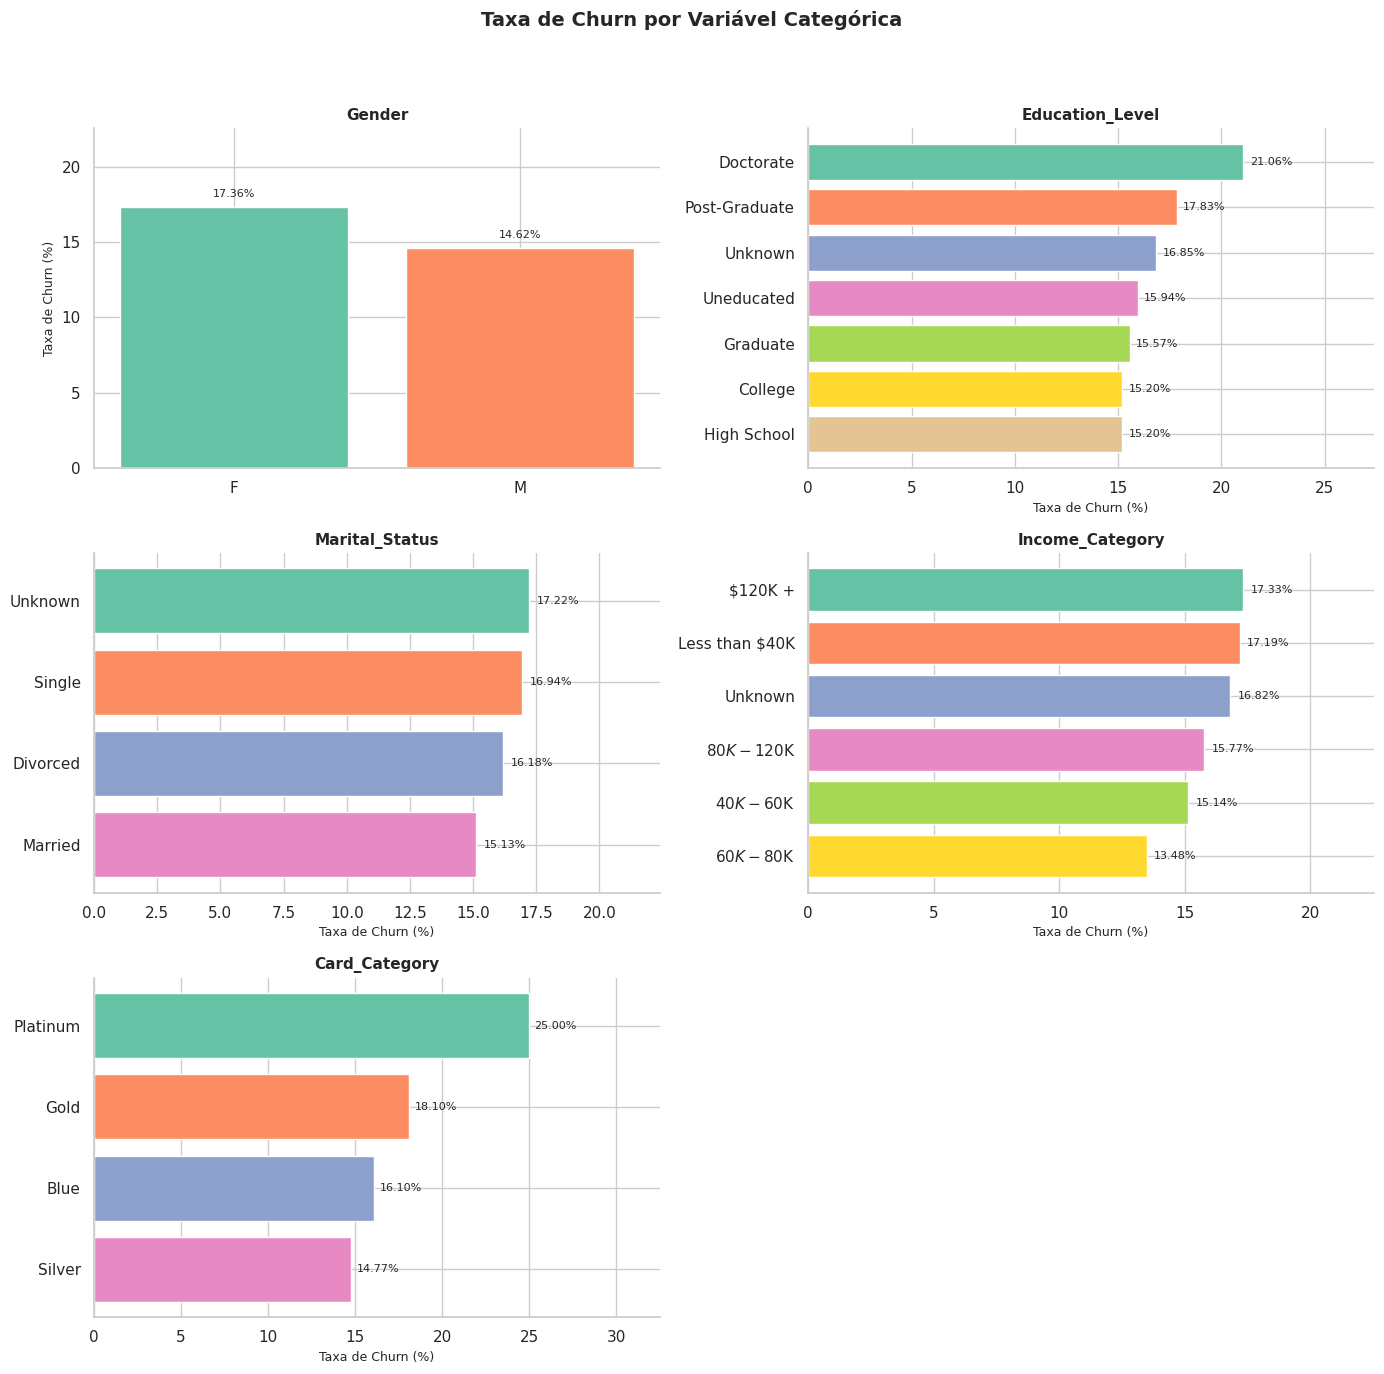

In [39]:
# Análise bivariada: taxa de churn por variável categórica

# Coluna auxiliar temporária para cálculo das taxas
churn_bin = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

categoricas = ['Gender', 'Education_Level', 'Marital_Status',
               'Income_Category', 'Card_Category']

# Variáveis com labels longos usam barras horizontais
horizontais = {'Income_Category', 'Education_Level', 'Marital_Status',
               'Card_Category'}

palette = sns.color_palette('Set2')
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

df_temp = df.assign(churn_bin=churn_bin)

for i, col in enumerate(categoricas):
    taxa = df_temp.groupby(col)['churn_bin'].mean() * 100
    # Ordem decrescente de taxa de churn
    ordem = taxa.sort_values(ascending=False).index.tolist()
    taxa = taxa.reindex(ordem)

    # Uma cor diferente para cada barra (igual ao padrão do bloco 4.4)
    cores = [palette[j % len(palette)] for j in range(len(ordem))]

    if col in horizontais:
        # barh plota de baixo para cima: inverter para o maior ficar no topo
        ordem_plot = ordem[::-1]
        taxa_plot = taxa.reindex(ordem_plot)
        cores_plot = cores[::-1]

        axes[i].barh(ordem_plot, taxa_plot.values, color=cores_plot)
        taxa_maxima = taxa.max()
        axes[i].set_xlim(0, taxa_maxima * 1.3)
        for j, valor_taxa in enumerate(taxa_plot.values):
            axes[i].text(valor_taxa + 0.3, j, f'{valor_taxa:.2f}%',
                         va='center', fontsize=8)
        axes[i].set_xlabel('Taxa de Churn (%)', fontsize=9)
        axes[i].set_ylabel('')
    else:
        # Gráfico vertical (Gender)
        axes[i].bar(ordem, taxa.values, color=cores)
        taxa_maxima = taxa.max()
        axes[i].set_ylim(0, taxa_maxima * 1.3)
        for j, valor_taxa in enumerate(taxa.values):
            axes[i].text(j, valor_taxa + taxa_maxima * 0.03,
                         f'{valor_taxa:.2f}%', ha='center', va='bottom', fontsize=8)
        axes[i].set_ylabel('Taxa de Churn (%)', fontsize=9)
        axes[i].set_xlabel('')

    axes[i].set_title(col, fontsize=11, fontweight='bold')

fig.delaxes(axes[5])
sns.despine(fig=fig)
plt.suptitle('Taxa de Churn por Variável Categórica', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Os gráficos revelam como a taxa de churn varia dentro de cada variável categórica. A taxa média geral do dataset é `16,07%` (conforme identificado na seção 4.1).

**Gender:** mulheres apresentam taxa de `17,36%`, levemente acima da média, enquanto homens ficam em `14,62%`. A diferença de `2,74` pontos percentuais sugere que o gênero tem influência modesta no churn.

**Education_Level:** resultado contra-intuitivo: clientes com Doctorate (`21,06%`) e Post-Graduate (`17,83%`) lideram o churn, enquanto College e High School têm a menor taxa (`15,20%`). Uma hipótese possível é que clientes mais escolarizados avaliam mais alternativas de crédito e trocam de produto com mais frequência.

**Marital_Status:** as diferenças são pequenas entre os grupos. Single (`16,94%`) e Unknown (`17,22%`) ficam levemente acima da média, enquanto Married (`15,13%`) fica abaixo. Nenhuma categoria apresenta desvio expressivo em relação à média geral.

**Income_Category:** padrão não-linear. As faixas de renda extremas lideram o churn: `$120K+` com `17,33%` e `Less than $40K` com `17,19%`, enquanto a faixa intermediária `$60K - $80K` tem a menor taxa (`13,48%`). Clientes de alta renda podem buscar produtos mais sofisticados, e os de baixa renda podem ter dificuldade de manter o relacionamento.

**Card_Category:** Platinum apresenta a maior taxa (`25,00%`), mas com apenas `20` clientes, o que torna essa porcentagem pouco confiável (uma base tão pequena pode gerar resultados muito diferentes se poucos clientes mudarem de grupo). Gold (`18,10%`) é mais representativo e está acima da média. Blue (`16,10%`) e Silver (`14,77%`) ficam próximos ou abaixo da média.

**Nota sobre "Unknown":** a categoria `Unknown` em `Education_Level`, `Marital_Status` e `Income_Category` representam dados ausentes (conforme identificado na seção 4.4). Suas taxas de churn são reportadas aqui para registro, mas devem ser interpretadas com cautela pois não é uma categoria real, e seu comportamento pode refletir omissão de informação pelo cliente em vez de um padrão genuíno. O tratamento desses valores será definido no Bloco 5.

## 4.7 Correlação

A correlação mede a força e a direção da relação entre duas variáveis numéricas. Nesta seção são usadas duas métricas complementares:

- **Pearson:** mede a relação *linear*. Sensível a outliers e assume distribuição aproximadamente normal. Varia entre `-1` e `1`.
- **Spearman:** mede a relação *monotônica*: quando uma variável sobe, a outra tende a subir (ou cair) de forma consistente, mas não necessariamente de forma proporcional. Trabalha com os *rankings* dos valores, sendo mais robusta a outliers e distribuições assimétricas.

O **heatmap** abaixo exibe a matriz de Pearson entre as `14` variáveis numéricas, cujo objetivo é identificar multicolinearidade (pares de variáveis que carregam informação muito parecida). Para esse fim, o Pearson é suficiente.

Já a comparação Pearson vs. Spearman é feita na **tabela de correlação com o target**, logo abaixo do heatmap. Como o dataset apresenta variáveis assimétricas e outliers (Seções 4.3 e 4.5), usar as duas métricas nessa tabela torna a análise mais robusta: onde ambas concordam, a conclusão é mais sólida; onde divergem, há um sinal de que outliers ou não-linearidade estão influenciando a relação. Como `Attrition_Flag` é uma string neste ponto do notebook, essa correlação é calculada usando uma versão codificada temporária (`Attrited Customer = 1`, `Existing Customer = 0`).

In [15]:
# Correlação com o target: Pearson e Spearman

colunas_num = df.select_dtypes(include='number').columns.tolist()
corr = df[colunas_num].corr()  # Pearson — usado no heatmap abaixo

# Codificação temporária do target (não salva no df)
target_enc = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Pearson e Spearman com o target
pearson_target = df[colunas_num].corrwith(target_enc, method='pearson').rename('Pearson r')
spearman_target = df[colunas_num].corrwith(target_enc, method='spearman').rename('Spearman ρ')

# Tabela comparativa, ordenada por Pearson crescente
comparacao = pd.concat([pearson_target, spearman_target], axis=1).round(4).sort_values('Pearson r')

print("Correlação das variáveis numéricas com o target (Attrited=1):\n")
print(comparacao.to_string())

Correlação das variáveis numéricas com o target (Attrited=1):

                          Pearson r  Spearman ρ
Total_Trans_Ct              -0.3714     -0.3761
Total_Ct_Chng_Q4_Q1         -0.2901     -0.3121
Total_Revolving_Bal         -0.2631     -0.2406
Avg_Utilization_Ratio       -0.1784     -0.2404
Total_Trans_Amt             -0.1686     -0.2238
Total_Relationship_Count    -0.1500     -0.1497
Total_Amt_Chng_Q4_Q1        -0.1311     -0.1020
Credit_Limit                -0.0239     -0.0509
Avg_Open_To_Buy             -0.0003      0.0275
Months_on_book               0.0137      0.0153
Customer_Age                 0.0182      0.0175
Dependent_count              0.0190      0.0210
Months_Inactive_12_mon       0.1524      0.1718
Contacts_Count_12_mon        0.2045      0.1890


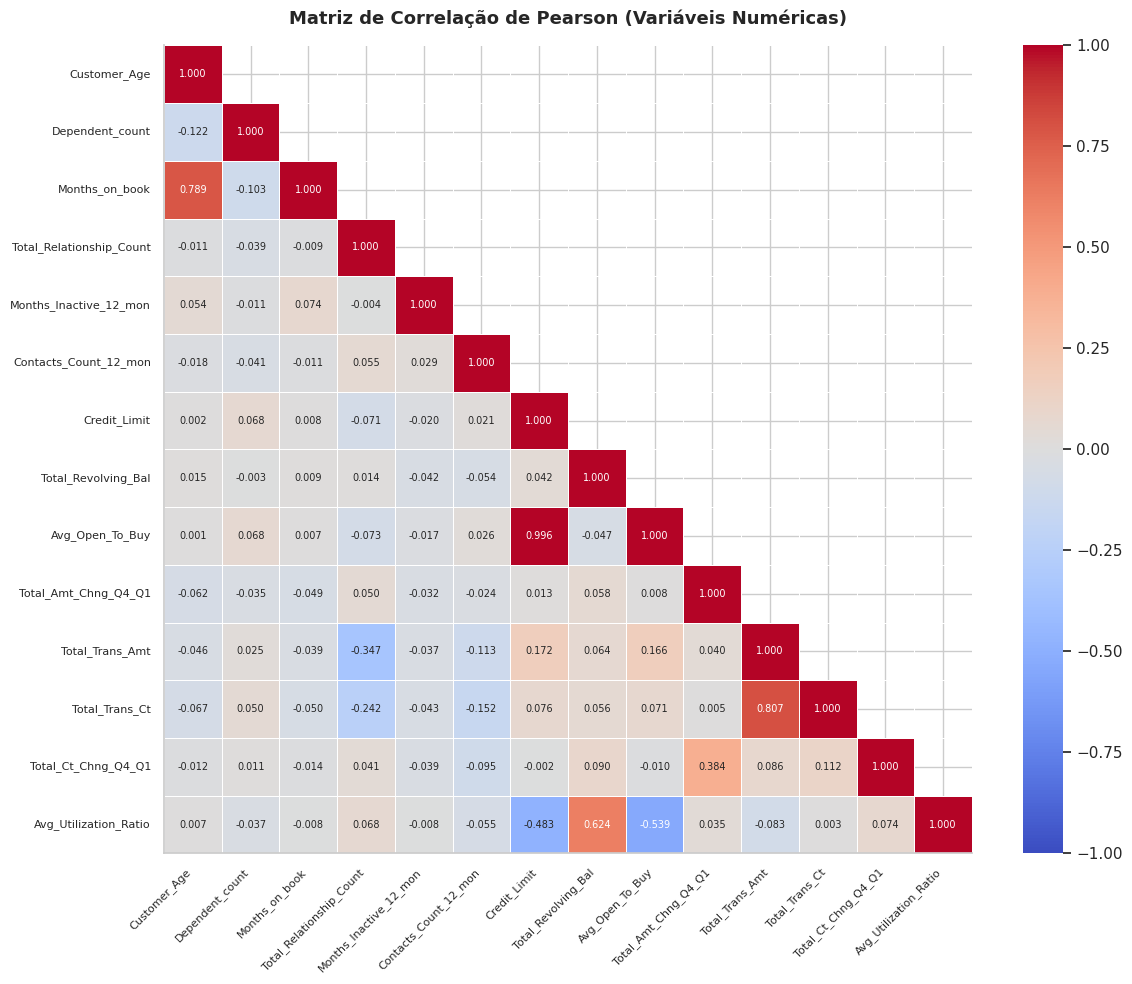

In [16]:
# Heatmap da matriz de correlação (triângulo inferior)
# figsize=(12,10): exceção necessária para 14x14 variáveis com anotações legíveis

fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1: mostra diagonal, mascara apenas triângulo superior

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_title('Matriz de Correlação de Pearson (Variáveis Numéricas)',
             fontsize=13, fontweight='bold', pad=15)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Pearson e Spearman concordam no ranking geral das variáveis:** as mesmas variáveis aparecem no topo em ambas as métricas, o que reforça a robustez dos achados mesmo com as distribuições assimétricas e outliers das Seções 4.3 e 4.5.

Nenhuma variável isolada tem correlação forte com o target. O maior valor em módulo é `|r| = 0,37` (Pearson) e `|ρ| = 0,38` (Spearman) para `Total_Trans_Ct`, indicando que o churn resulta da combinação de múltiplos fatores, não de um único preditor dominante.

**Correlações negativas mais relevantes:** `Total_Trans_Ct` (`-0,37` / `-0,38`) e `Total_Ct_Chng_Q4_Q1` (`-0,29` / `-0,31`) lideram nas duas métricas. Clientes com menor volume de transações tendem mais ao churn, confirmando os padrões visuais dos boxplots da Seção 4.5.

**Principal divergência entre Pearson e Spearman:** `Avg_Utilization_Ratio` tem Pearson de `-0,18` e Spearman de `-0,24`. A diferença indica que a relação com o target é mais intensa do que o Pearson sugere, mas não de forma linear, o que é consistente com a distribuição bimodal e o pico em zero observados na Seção 4.3. O mesmo padrão aparece em `Total_Trans_Amt` (Pearson `-0,17`, Spearman `-0,22`), onde os outliers da variável reduzem artificialmente a correlação linear.

**Correlações positivas mais relevantes:** `Contacts_Count_12_mon` (`+0,20` / `+0,19`) e `Months_Inactive_12_mon` (`+0,15` / `+0,17`) também concordam entre as duas métricas. Mais contatos com o banco e maior inatividade estão associados a maior churn, consistente com a Seção 4.5.

**Multicolinearidade (variáveis que repetem a mesma informação):** três pares de variáveis apresentam `|r| > 0,70` no heatmap de Pearson. O mais crítico é `Credit_Limit` × `Avg_Open_To_Buy` (`r = 0,9960`), que carregam informação quase idêntica, como a diferença de escala já indicava na Seção 4.2. Os pares `Total_Trans_Amt` / `Total_Trans_Ct` (`r = 0,8072`) e `Customer_Age` / `Months_on_book` (`r = 0,7889`) também apresentam alta redundância. O Bloco 5 considerará remover ou combinar uma variável de cada par para evitar redundância no modelo.

**Fechando o loop da Seção 4.2:** os dois pares com estatísticas descritivas semelhantes mostraram resultados opostos no heatmap. `Months_Inactive_12_mon` × `Contacts_Count_12_mon` têm `r = 0,03`, confirmando que distribuições similares não implicam correlação: as duas variáveis medem fenômenos independentes e serão mantidas. Já `Total_Amt_Chng_Q4_Q1` × `Total_Ct_Chng_Q4_Q1` têm `r = 0,38`, correlação moderada e esperada, pois um cliente que reduz o número de transações tende a reduzir também o valor transacionado. Ainda assim, `r = 0,38` está abaixo do limiar de `0,70` adotado na Seção 5.1 para candidatos à remoção: ambas as variáveis serão mantidas no dataset.

## 4.8 Verificação de Valores Nulos e "Unknown"

Antes de avançar para o pré-processamento, é essencial verificar a presença de valores faltantes no dataset. Existem dois tipos de missing values a identificar:

1. **NaN explícitos:** células vazias reconhecidas pelo pandas. Identificadas com `isnull()`.
2. **Missing values disfarçados:** valores textuais como `"Unknown"` que, na prática, indicam ausência de informação. Essa é uma armadilha frequente em datasets reais.

As células abaixo verificam os dois casos separadamente.

In [17]:
# Verificação de valores NaN explícitos por coluna
nulos = df.isnull().sum()
print(f"Total de valores nulos no dataset: {nulos.sum()}")
print("\nNulos por coluna:")
print(nulos.to_string())

Total de valores nulos no dataset: 0

Nulos por coluna:
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0


In [18]:
# Verificação de "Unknown" como proxy de missing value
colunas_unknown = ['Education_Level', 'Marital_Status', 'Income_Category']

print("Ocorrências de 'Unknown' por variável:\n")
for col in colunas_unknown:
    contagem = (df[col] == 'Unknown').sum()
    percentual = contagem / len(df) * 100
    print(f"  {col}: {contagem} ocorrências ({percentual:.2f}% do dataset)")

total = sum((df[col] == 'Unknown').sum() for col in colunas_unknown)
print(f"\nTotal de 'Unknown' nas 3 variáveis: {total}")

Ocorrências de 'Unknown' por variável:

  Education_Level: 1519 ocorrências (15.00% do dataset)
  Marital_Status: 749 ocorrências (7.40% do dataset)
  Income_Category: 1112 ocorrências (10.98% do dataset)

Total de 'Unknown' nas 3 variáveis: 3380


O dataset não contém nenhum valor `NaN` explícito: `0` nulos em todas as `20` colunas utilizadas. Isso indica que o processo de coleta original não gerou células vazias reconhecidas pelo pandas.

Entretanto, há `3.380` ocorrências de `"Unknown"` distribuídas em três variáveis categóricas: `Education_Level` (`1.519` casos, `15,00%`), `Income_Category` (`1.112` casos, `10,98%`) e `Marital_Status` (`749` casos, `7,40%`). Como observado na seção 4.4, essas categorias aparecem explicitamente nas barras dos countplots como categorias regulares.

Esses "Unknown" são missing values disfarçados e precisam de tratamento no Bloco 5. As estratégias possíveis incluem: manter como categoria própria (preservando a informação de ausência de resposta do cliente), substituir pelo valor mais frequente (moda) da variável, ou remover as linhas afetadas. A escolha dependerá da estratégia de pré-processamento adotada.

# Bloco 5: Pré-Processamento de Dados

O pré-processamento é a etapa em que transformamos os dados brutos em um formato adequado para algoritmos de aprendizado de máquina. Seu objetivo é corrigir problemas identificados na EDA, codificar variáveis categóricas, escalar valores numéricos e gerar versões do dataset prontas para modelagem.

Neste bloco, o pré-processamento está organizado nas seguintes subseções:
1. **Tratamento de multicolinearidade**, remoção de variáveis redundantes identificadas na Seção 4.7
2. **Tratamento dos "Unknown"**, decisão sobre os valores ausentes disfarçados contabilizados na Seção 4.8
3. **Encoding de variáveis categóricas**, conversão de texto em números (Label, Ordinal e One-Hot Encoding)
4. **Separação features/target e split treino/teste**, isolamento da variável-alvo e particionamento estratificado
5. **Normalização**, reescala para o intervalo `[0, 1]` considerando as escalas distintas observadas na Seção 4.2
6. **Padronização**, transformação para média `0` e desvio padrão `1` com Standard Scaler
7. **Outras transformações**, transformação logarítmica, discretização, outliers e feature engineering, orientadas pelas assimetrias (Seção 4.3) e outliers (Seção 4.5)
8. **Salvamento das versões**, geração de múltiplas versões do dataset para uso futuro

A ordem das etapas segue uma lógica de dependência: a multicolinearidade é tratada primeiro para reduzir redundância antes de qualquer transformação. Os "Unknown" são resolvidos enquanto as variáveis ainda são texto, antes do encoding convertê-las em números. O split treino/teste antecede normalização e padronização para evitar vazamento de dados (data leakage). As demais transformações são aplicadas por último, sobre os dados já particionados.

## 5.1 Tratamento de Multicolinearidade

Multicolinearidade ocorre quando duas ou mais variáveis numéricas são altamente correlacionadas entre si, de modo que uma pode ser prevista a partir da outra. Para algoritmos de aprendizado de máquina, variáveis redundantes aumentam a complexidade sem acrescentar informação nova e podem prejudicar a interpretabilidade dos resultados.

O critério adotado tem duas etapas: primeiro, o código lista todos os pares com correlação de Pearson absoluta `>= 0,70` para análise visual. Em seguida, apenas os pares que ultrapassam `0,90` têm a variável menos relevante removida. Esse intervalo entre `0,70` e `0,90` serve como zona de atenção: pares nessa faixa são avaliados, mas mantidos se carregarem informação distinta (como visto na Seção 4.7).

Na Seção 4.7, o heatmap de correlação já sinalizou os pares suspeitos. Nesta seção, esses pares são identificados programaticamente e as variáveis redundantes são removidas antes de qualquer outra transformação.

O pré-processamento parte de uma cópia do `df` limpo, preservando o original intacto para referência.

In [19]:
# Cópia do df limpo para pré-processamento (preserva o original intacto)
df_prep = df.copy()

# Correlação de Pearson absoluta entre variáveis numéricas
limiar = 0.70  # lista candidatos; remoção efetiva apenas acima de 0,90
colunas_num = df_prep.select_dtypes(include='number').columns.tolist()
corr_abs = df_prep[colunas_num].corr(method='pearson').abs()

# Triângulo superior: evita duplicar pares e exclui a diagonal principal
mascara_upper = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
upper = corr_abs.where(mascara_upper)

# Identificar pares com correlação acima do limiar
pares = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val >= limiar:
            pares.append((row, col, val))

print(f"Pares com correlação de Pearson |r| >= {limiar}:\n")
if pares:
    for v1, v2, r in sorted(pares, key=lambda x: x[2], reverse=True):
        print(f"  {v1:30s}  x  {v2:30s}  r = {r:.4f}")
else:
    print("  Nenhum par encontrado.")

Pares com correlação de Pearson |r| >= 0.7:

  Credit_Limit                    x  Avg_Open_To_Buy                 r = 0.9960
  Total_Trans_Amt                 x  Total_Trans_Ct                  r = 0.8072
  Customer_Age                    x  Months_on_book                  r = 0.7889


In [20]:
# Avg_Open_To_Buy é derivado diretamente de Credit_Limit − Total_Revolving_Bal,
# tornando-a redundante. Mantemos Credit_Limit por ser mais interpretável
# (representa o limite contratado, independente do saldo devedor).
colunas_remover = ['Avg_Open_To_Buy']
df_prep.drop(columns=colunas_remover, inplace=True)

print(f"Variável(is) removida(s): {colunas_remover}")
print(f"\ndf_prep: {df_prep.shape[0]} linhas x {df_prep.shape[1]} colunas")
print(f"\nColunas restantes:\n  {df_prep.columns.tolist()}")

Variável(is) removida(s): ['Avg_Open_To_Buy']

df_prep: 10127 linhas x 19 colunas

Colunas restantes:
  ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Apenas um par ultrapassou o limiar de `0,90`: `Credit_Limit` × `Avg_Open_To_Buy`, com correlação de Pearson de `r = 0,9960`. Essa correlação quase perfeita confirma a suspeita levantada pelo heatmap da Seção 4.7: as duas variáveis carregam praticamente a mesma informação.

A razão matemática é direta. `Avg_Open_To_Buy` representa o crédito disponível ao cliente e é calculada como `Credit_Limit − Total_Revolving_Bal`. Ou seja, seu valor é inteiramente derivado de duas outras variáveis já presentes no dataset. Manter ambas não acrescentaria poder preditivo ao modelo, apenas redundância. `Avg_Open_To_Buy` foi removida e `Credit_Limit` mantida, por representar o limite contratado de forma mais direta e interpretável.

Dois outros pares ficaram abaixo do limiar e foram mantidos. `Total_Trans_Amt` × `Total_Trans_Ct` (`r = 0,8072`) mostraram padrões distintos nos boxplots da Seção 4.5, com separações diferentes entre os grupos: `Total_Trans_Ct` com medianas `43` vs `71` e `Total_Trans_Amt` com medianas `2.329` vs `4.100`. Além disso, na Seção 4.7, cada uma apresentou correlação diferente com o target: `Total_Trans_Ct` com `r = -0,3700` e `Total_Trans_Amt` com `r = -0,1700`. Informações preditivas distintas, portanto sem redundância. O par `Customer_Age` × `Months_on_book` (`r = 0,7889`) também foi mantido, pois medem conceitos diferentes: a primeira é a idade do cliente, a segunda o tempo de relacionamento com o banco.

Após a remoção, `df_prep` contém `10.127` linhas e `19` colunas, prontas para as próximas etapas de pré-processamento.

## 5.2 Tratamento dos "Unknown"

Como identificado na Seção 4.8, três variáveis categóricas contêm a categoria `"Unknown"` como proxy de valor ausente: `Education_Level` (`1.519` casos, `15,00%`), `Income_Category` (`1.112` casos, `10,98%`) e `Marital_Status` (`749` casos, `7,40%`).

Há três estratégias possíveis para lidar com esses valores:

- **Remover as linhas:** elimina a ambiguidade, mas descarta dados. Como um cliente pode ter `"Unknown"` em mais de uma coluna, o número de linhas únicas afetadas precisa ser calculado.
- **Substituir pela moda:** preenche com o valor mais frequente da variável. É simples, mas introduz informação que não existia e dilui possíveis padrões do grupo que não respondeu.
- **Manter como categoria própria:** preserva a informação de que o cliente não declarou aquele dado. Se o comportamento dos clientes `"Unknown"` for diferente dos demais, essa categoria terá valor preditivo para o modelo.

O código abaixo quantifica o impacto de cada opção e verifica se `"Unknown"` está associado a taxas de churn distintas.

In [21]:
# Variáveis com "Unknown" como proxy de missing value
variaveis_unknown = ['Education_Level', 'Marital_Status', 'Income_Category']

# 1. Contagem e percentual por variável
print("Distribuição de 'Unknown' por variável:")
print("-" * 50)
for col in variaveis_unknown:
    n = (df_prep[col] == 'Unknown').sum()
    pct = n / len(df_prep) * 100
    moda = df_prep[df_prep[col] != 'Unknown'][col].mode()[0]
    print(f"  {col:20s}: {n:5d} ({pct:.2f}%)  |  moda (sem Unknown): {moda}")

# 2. Linhas únicas afetadas (um cliente pode ter Unknown em mais de uma coluna)
mask_any = df_prep[variaveis_unknown].eq('Unknown').any(axis=1)
n_afetadas = mask_any.sum()
pct_afetadas = n_afetadas / len(df_prep) * 100
print(f"\nLinhas com pelo menos um 'Unknown': {n_afetadas} ({pct_afetadas:.2f}%)")

# 3. Taxa de churn nos grupos "Unknown" vs. demais (verifica se Unknown é informativo)
print("\nTaxa de churn: 'Unknown' vs. demais categorias")
print("-" * 50)
for col in variaveis_unknown:
    mask_unk = df_prep[col] == 'Unknown'
    churn_unk = (df_prep.loc[mask_unk, 'Attrition_Flag'] == 'Attrited Customer').mean() * 100
    churn_nao = (df_prep.loc[~mask_unk, 'Attrition_Flag'] == 'Attrited Customer').mean() * 100
    print(f"  {col:20s}: Unknown={churn_unk:.2f}%  |  demais={churn_nao:.2f}%")

Distribuição de 'Unknown' por variável:
--------------------------------------------------
  Education_Level     :  1519 (15.00%)  |  moda (sem Unknown): Graduate
  Marital_Status      :   749 (7.40%)  |  moda (sem Unknown): Married
  Income_Category     :  1112 (10.98%)  |  moda (sem Unknown): Less than $40K

Linhas com pelo menos um 'Unknown': 3046 (30.08%)

Taxa de churn: 'Unknown' vs. demais categorias
--------------------------------------------------
  Education_Level     : Unknown=16.85%  |  demais=15.93%
  Marital_Status      : Unknown=17.22%  |  demais=15.97%
  Income_Category     : Unknown=16.82%  |  demais=15.97%


As contagens confirmam o que foi identificado na Seção 4.8: `Education_Level` tem `1.519` casos (`15,00%`), `Income_Category` tem `1.112` (`10,98%`) e `Marital_Status` tem `749` (`7,40%`). A soma desses três totais seria `3.380`, mas o número de linhas únicas afetadas é `3.046` (`30,08%`), o que indica que parte dos clientes tem `"Unknown"` em mais de uma variável ao mesmo tempo. Remover essas linhas significaria perder quase um terço do dataset, o que inviabiliza essa estratégia.

A substituição pela moda também não é adequada neste caso. A moda de `Education_Level` é `Graduate`, a de `Marital_Status` é `Married` e a de `Income_Category` é `Less than $40K`. Substituir `"Unknown"` por esses valores criaria informação que não existe: um cliente que não declarou sua renda passaria a "ter" a faixa `Less than $40K`, diluindo qualquer padrão associado à ausência de resposta.

Os dados de churn mostram que `"Unknown"` tem taxa acima da média das demais categorias agrupadas em todas as três variáveis: `16,85%` vs `15,93%` em `Education_Level`, `17,22%` vs `15,97%` em `Marital_Status` e `16,82%` vs `15,97%` em `Income_Category`. Isso não significa que `"Unknown"` tem o maior churn dentro de cada variável: em `Education_Level`, Doctorate (`21,06%`) e Post-Graduate (`17,83%`) ficam acima, e em `Income_Category`, `$120K+` (`17,33%`) e `Less than $40K` (`17,19%`) também superam `"Unknown"`. O que os dados mostram é que substituir `"Unknown"` pela moda (`Graduate`, `Married` ou `Less than $40K`) atribuiria esses clientes a categorias com taxas de churn menores, apagando uma diferença real de comportamento.

A decisão é manter `"Unknown"` como categoria própria. Ele será codificado como as demais categorias no One-Hot Encoding da Seção 5.3, preservando a informação de que o cliente optou por não informar aquele dado.

## 5.3 Encoding de Variáveis Categóricas

Antes de treinar qualquer modelo, todas as variáveis categóricas precisam ser convertidas para números. Existem três abordagens principais, e a escolha depende da natureza de cada variável:

**Label Encoding** transforma uma variável binária em `0` e `1`. É usado aqui apenas para o target `Attrition_Flag`, pois tem exatamente duas categorias e não existe ordem entre elas, apenas presença ou ausência de churn.

**Ordinal Encoding** atribui inteiros seguindo a ordem natural das categorias. É a escolha correta quando existe uma hierarquia real entre os valores:
- `Education_Level`: de `Uneducated` (`1`) a `Doctorate` (`6`). `Unknown` recebe `0` para indicar ausência de informação, fora da escala de escolaridade.
- `Income_Category`: de `Less than $40K` (`1`) a `$120K +` (`5`). `Unknown` recebe `0` pelo mesmo motivo.
- `Card_Category`: de `Blue` (`1`) a `Platinum` (`4`), seguindo a hierarquia de prestígio dos cartões.

**One-Hot Encoding (OHE)** cria uma coluna binária para cada categoria. É usado nas variáveis nominais, onde não existe ordem entre os valores:
- `Gender`: `Male` e `Female` não têm hierarquia.
- `Marital_Status`: `Married`, `Single`, `Divorced` e `Unknown` também não têm ordem natural. O `Unknown` será preservado como coluna própria, mantendo o sinal identificado na Seção 5.2.

As colunas binárias geradas pelo OHE **não serão incluídas** na normalização e padronização das Seções 5.8 e 5.9, pois já estão na escala `0/1`.

In [22]:
# Cópia de df_prep para aplicar todos os encodings
df_encoded = df_prep.copy()

# Label Encoding do target: Existing Customer → 0, Attrited Customer → 1
df_encoded['Attrition_Flag'] = df_encoded['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

print('Distribuição do target após Label Encoding:')
print(df_encoded['Attrition_Flag'].value_counts())
print(f"0 = Existing Customer | 1 = Attrited Customer")

Distribuição do target após Label Encoding:
Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64
0 = Existing Customer | 1 = Attrited Customer


In [23]:
# Ordinal Encoding: mapeamento explícito respeitando a ordem natural de cada variável
# Unknown recebe 0 em todas (fora da escala, indica ausência de informação)

Education_Level = {
    'Unknown': 0,
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6
}

Income_Category = {
    'Unknown': 0,
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5
}

Card_Category = {
    'Blue': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4
}

df_encoded['Education_Level'] = df_encoded['Education_Level'].map(Education_Level)
df_encoded['Income_Category'] = df_encoded['Income_Category'].map(Income_Category)
df_encoded['Card_Category']   = df_encoded['Card_Category'].map(Card_Category)

print('Contagem por valor codificado:')
print(df_encoded['Education_Level'].value_counts().sort_index())
print()
print(df_encoded['Income_Category'].value_counts().sort_index())
print()
print(df_encoded['Card_Category'].value_counts().sort_index())

Contagem por valor codificado:
Education_Level
0    1519
1    1487
2    2013
3    1013
4    3128
5     516
6     451
Name: count, dtype: int64

Income_Category
0    1112
1    3561
2    1790
3    1402
4    1535
5     727
Name: count, dtype: int64

Card_Category
1    9436
2     555
3     116
4      20
Name: count, dtype: int64


In [24]:
# One-Hot Encoding para Gender e Marital_Status (variáveis nominais sem ordem natural)
# dtype=int converte os valores booleanos para 0/1
df_encoded = pd.get_dummies(df_encoded, columns=['Gender', 'Marital_Status'], dtype=int)

# Identificar as colunas binárias criadas pelo OHE
# (serão excluídas da normalização e padronização nas Seções 5.8 e 5.9)
colunas_ohe = [c for c in df_encoded.columns if c.startswith(('Gender_', 'Marital_Status_'))]
print('Colunas binárias criadas pelo OHE:')
print(colunas_ohe)

print(f'Shape de df_encoded: {df_encoded.shape}')
print('Tipos de dados de df_encoded:')
print(df_encoded.dtypes)

Colunas binárias criadas pelo OHE:
['Gender_F', 'Gender_M', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown']
Shape de df_encoded: (10127, 23)
Tipos de dados de df_encoded:
Attrition_Flag                int64
Customer_Age                  int64
Dependent_count               int64
Education_Level               int64
Income_Category               int64
Card_Category                 int64
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
Gender_F                      int64
Gender_M                      int64
Marital_Status_Divorced       int64
Marital_Status_Married        int64
Marital_Status_Si

In [25]:
df_encoded.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_F,Gender_M,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,0,45,3,2,3,1,39,5,1,3,...,1144,42,1.625,0.061,0,1,0,1,0,0
1,0,49,5,4,1,1,44,6,1,2,...,1291,33,3.714,0.105,1,0,0,0,1,0
2,0,51,3,4,4,1,36,4,1,0,...,1887,20,2.333,0.000,0,1,0,1,0,0
3,0,40,4,2,1,1,34,3,4,1,...,1171,20,2.333,0.760,1,0,0,0,0,1
4,0,40,3,1,3,1,21,5,1,0,...,816,28,2.500,0.000,0,1,0,1,0,0


O encoding transformou todas as variáveis categóricas em representações numéricas sem introduzir distorções ou perdas de dados.

**Label Encoding** manteve a proporção original do target: `8.500` clientes sem churn (código `0`, `83,93%`) e `1.627` com churn (código `1`, `16,07%`), confirmando que a conversão não alterou a distribuição identificada na Seção 4.1.

**Ordinal Encoding** concluiu sem nenhum valor ausente (`0` NaN nas três colunas), o que confirma que todos os valores presentes no CSV correspondem exatamente às categorias mapeadas. O código `0` reservado para `Unknown` preserva a decisão tomada na Seção 5.2: esses casos não representam ausência de resposta dentro da escala de escolaridade ou renda, mas sim ausência de informação sobre a escala, por isso ficam fora dela.

**One-Hot Encoding** expandiu as duas variáveis nominais em `6` colunas binárias: `Gender_F` (`52,9%`) e `Gender_M` (`47,1%`) para gênero; `Marital_Status_Married` (`46,3%`), `Marital_Status_Single` (`38,9%`), `Marital_Status_Divorced` (`7,4%`) e `Marital_Status_Unknown` (`7,4%`) para estado civil. A coluna `Marital_Status_Unknown` foi mantida intencionalmente, preservando o padrão identificado na Seção 5.2, onde clientes com estado civil desconhecido apresentaram taxa de churn distinta das demais categorias.

O `df_encoded` resultante tem `23` colunas (eram `19` em `df_prep`), todas do tipo numérico (`int64` ou `float64`), e está pronto para as próximas etapas do pré-processamento.

## 5.4 Tratamento de Outliers

Outliers são valores muito distantes do restante dos dados. Podem surgir de erros de coleta, casos raros ou simplesmente clientes com perfis bem diferentes da maioria. O problema é que eles distorcem os parâmetros calculados na normalização e na padronização: um único valor extremo pode puxar o máximo para cima e comprimir todos os outros valores.

O método usado para identificar outliers é o **IQR (Intervalo Interquartil)**: a diferença entre o terceiro quartil (`Q3`, percentil 75) e o primeiro quartil (`Q1`, percentil 25). Os limites são:

- Limite inferior: `Q1 − 1,5 × IQR`
- Limite superior: `Q3 + 1,5 × IQR`

Valores fora desse intervalo são considerados outliers. Para variáveis que não admitem valores negativos (contagens, saldos, valores monetários), o limite inferior é ajustado para `0`, que representa o piso real da variável.

A estratégia de tratamento escolhida é o **capping** (também chamado de winsorização): em vez de remover a linha, o valor extremo é substituído pelo limite mais próximo. O cliente continua no dataset, mas seu valor não distorce os cálculos.

O capping é aplicado agora, antes da separação treino/teste da Seção 5.7, porque os parâmetros de normalização e padronização precisam ser calculados em dados já tratados.

**Nem toda variável com outliers deve ser cappeada.** A tabela abaixo apresenta as principais candidatas e a decisão para cada uma:

| Variável | Outliers | Decisão | Motivo |
|---|---|---|---|
| `Credit_Limit` | `9,72%` | Capping | Cauda longa à direita, sem dois grupos distintos. O valor máximo (`34.516`) é `45%` acima do limite (`23.836`): distorção real na normalização |
| `Total_Trans_Amt` | `8,85%` | Sem capping | O histograma da Seção 4.3 mostra dois grupos de clientes: um de baixo volume e outro de alto volume. Os valores altos não são erros, são um padrão real |
| `Contacts_Count_12_mon` | `6,21%` | Sem capping | Variável que conta de `0` a `6` contatos. Os "outliers" são os valores `5` e `6`, que são categorias válidas dentro de um intervalo natural |
| `Total_Amt_Chng_Q4_Q1` | `3,91%` | Sem capping | A assimetria será reduzida pela transformação logarítmica da Seção 5.6, que é mais adequada para variáveis que medem variação percentual |
| `Total_Ct_Chng_Q4_Q1` | `3,89%` | Sem capping | Mesmo motivo que `Total_Amt_Chng_Q4_Q1` |
| `Months_on_book` | `3,81%` | Sem capping | Distribuição equilibrada (sem inclinação forte). Os "outliers" são clientes com `54`-`56` meses de relacionamento, menos de `3` meses acima do limite: impacto mínimo |
| `Total_Revolving_Bal` | `0,00%` | Sem capping | Não há outliers pelo IQR. O pico em zero é um padrão real: clientes que cancelam com frequência não têm saldo rotativo (Seção 4.5) |

In [26]:
# Variáveis contínuas originais (excluindo OHE, ordinais e target)
colunas_analise = [
    'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Calcular Q1, Q3, IQR e contar outliers por variável
# Lim. Inferior usa max(0, valor_calculado): o IQR pode produzir limites negativos
# para variáveis que não admitem valores negativos (ex: crédito, saldo, contagens)
registros = []
for col in colunas_analise:
    Q1  = df_encoded[col].quantile(0.25)
    Q3  = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = max(0, Q1 - 1.5 * IQR)
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((df_encoded[col] < lim_inf) | (df_encoded[col] > lim_sup)).sum()
    registros.append({
        'Variável'      : col,
        'Lim. Inferior' : round(lim_inf, 2),
        'Lim. Superior' : round(lim_sup, 2),
        'Outliers'      : n_out,
        '%'             : f"{n_out / len(df_encoded) * 100:.2f}%"
    })

df_iqr = pd.DataFrame(registros)
print(df_iqr.to_string(index=False))

                Variável  Lim. Inferior  Lim. Superior  Outliers     %
            Customer_Age          24.50          68.50         2 0.02%
         Dependent_count           0.00           6.00         0 0.00%
          Months_on_book          17.50          53.50       386 3.81%
Total_Relationship_Count           0.00           8.00         0 0.00%
  Months_Inactive_12_mon           0.50           4.50       331 3.27%
   Contacts_Count_12_mon           0.50           4.50       629 6.21%
            Credit_Limit           0.00       23836.25       984 9.72%
     Total_Revolving_Bal           0.00        3921.50         0 0.00%
    Total_Amt_Chng_Q4_Q1           0.29           1.20       396 3.91%
         Total_Trans_Amt           0.00        8619.25       896 8.85%
          Total_Trans_Ct           0.00         135.00         2 0.02%
     Total_Ct_Chng_Q4_Q1           0.23           1.17       394 3.89%
   Avg_Utilization_Ratio           0.00           1.22         0 0.00%


In [27]:
# Capping do limite superior de Credit_Limit pelo critério IQR
Q1_cl      = df_encoded['Credit_Limit'].quantile(0.25)
Q3_cl      = df_encoded['Credit_Limit'].quantile(0.75)
lim_sup_cl = Q3_cl + 1.5 * (Q3_cl - Q1_cl)

n_antes = (df_encoded['Credit_Limit'] > lim_sup_cl).sum()
df_encoded['Credit_Limit'] = df_encoded['Credit_Limit'].clip(upper=lim_sup_cl)
n_depois = (df_encoded['Credit_Limit'] > lim_sup_cl).sum()

print(f"Credit_Limit — limite superior IQR : {lim_sup_cl:.2f}")
print(f"Registros cappeados                : {n_antes}")
print(f"Outliers restantes após capping    : {n_depois}")
print(f"Valor máximo após capping          : {df_encoded['Credit_Limit'].max():.2f}")

Credit_Limit — limite superior IQR : 23836.25
Registros cappeados                : 984
Outliers restantes após capping    : 0
Valor máximo após capping          : 23836.25


A tabela mostra que a maioria das variáveis está dentro do esperado pelo critério IQR. Quatro delas (`Dependent_count`, `Total_Relationship_Count`, `Total_Revolving_Bal` e `Avg_Utilization_Ratio`) não apresentam nenhum outlier. `Customer_Age` e `Total_Trans_Ct` têm apenas `2` casos cada (`0,02%`), sem impacto prático.

As três variáveis com maior concentração de outliers são `Credit_Limit` (`9,72%`), `Total_Trans_Amt` (`8,85%`) e `Contacts_Count_12_mon` (`6,21%`). Somente `Credit_Limit` foi cappeada. As demais foram mantidas pelos motivos descritos no início desta seção: `Total_Trans_Amt` tem distribuição com dois grupos distintos (Seção 4.3) e `Contacts_Count_12_mon` é uma variável de contagem com intervalo natural de `0` a `6`, onde os valores `5` e `6` são categorias reais, não erros.

Seis variáveis exibem `0,00` no limite inferior: `Credit_Limit`, `Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Revolving_Bal`, `Avg_Utilization_Ratio` e `Dependent_count`. O cálculo IQR produzia valores negativos para essas colunas, mas valores negativos são impossíveis pelo domínio (crédito, transações, saldo e número de dependentes não podem ser negativos). O limite foi ajustado para `0,00`, que é o piso real de cada uma. Na prática, isso confirma que nenhuma dessas variáveis tem outliers inferiores.

Após o capping de `Credit_Limit`, `0` outliers restaram. O valor máximo passou de `34.516,00` para `23.836,25` e a média reduziu de `8.631,95` para `7.882,31`, uma queda de aproximadamente `9%`. Essa redução reflete exatamente o efeito que motivou o tratamento: os valores extremos estavam puxando a distribuição para cima e distorceriam os parâmetros de normalização da Seção 5.8.

## 5.5 Variáveis Derivadas

As variáveis originais do dataset medem grandezas absolutas: o total de transações realizadas, o valor total movimentado, o número de contatos recebidos. Sozinhas, essas grandezas são difíceis de comparar entre clientes com perfis distintos. Um cliente com `100` transações e `5` anos de relacionamento não é necessariamente mais ativo do que um com `60` transações e `2` anos. A criação de variáveis derivadas resolve esse problema combinando colunas existentes em razões que normalizam o valor pelo contexto do cliente.

As quatro variáveis criadas a seguir foram escolhidas com base nos padrões identificados na EDA e nas hipóteses do Bloco 2:

- **`Avg_Transaction_Value`**: `Total_Trans_Amt / Total_Trans_Ct`. Um cliente com `Total_Trans_Amt` elevado pode ter poucas transações de alto valor ou muitas transações pequenas. O valor médio por transação diferencia esses dois perfis, que possivelmente têm comportamentos de churn distintos.

- **`Transaction_per_Month`**: `Total_Trans_Ct / Months_on_book`. Normaliza a frequência de transações pelo tempo de relacionamento com o banco. Permite comparar clientes novos com clientes antigos sem o viés do tempo: um cliente com `2` anos de conta naturalmente acumula mais transações do que um com `6` meses.

- **`Utilization_Category`**: faixa de utilização do limite de crédito derivada de `Avg_Utilization_Ratio`. Converte a razão contínua em `3` faixas interpretáveis: `0` para baixa utilização (< `0,3`), `1` para média (`0,3` a `0,7`) e `2` para alta (> `0,7`). Diretamente relevante para a hipótese H2 (Seção 2.2). Codificada como ordinal numérica para manter `df_encoded` inteiramente numérico, requisito das etapas de normalização e padronização das Seções 5.8 e 5.9.

- **`Contacts_per_Inactive_Month`**: `Contacts_Count_12_mon / (Months_Inactive_12_mon + 1)`. Mede o esforço de retenção do banco por mês de inatividade do cliente. O `+1` no denominador evita divisão por zero nos casos em que `Months_Inactive_12_mon = 0`. Conecta com a hipótese H1 (Seção 2.2): se inatividade está associada a churn, clientes com mais contatos por mês inativo podem ser aqueles que o banco tentou recuperar.

Todas as variáveis são criadas antes da separação treino/teste (Seção 5.7) para que sejam normalizadas e padronizadas junto com as demais na mesma escala.

In [28]:
# Avg_Transaction_Value: valor médio por transação
df_encoded['Avg_Transaction_Value'] = (
    df_encoded['Total_Trans_Amt'] / df_encoded['Total_Trans_Ct']
)

# Transaction_per_Month: transações médias por mês de relacionamento
df_encoded['Transaction_per_Month'] = (
    df_encoded['Total_Trans_Ct'] / df_encoded['Months_on_book']
)

# Utilization_Category: faixa de utilização do limite de crédito
# Ordinal: 0 = Low (< 0.3), 1 = Medium (0.3–0.7), 2 = High (> 0.7)
conditions = [
    df_encoded['Avg_Utilization_Ratio'] < 0.3,
    (df_encoded['Avg_Utilization_Ratio'] >= 0.3) & (df_encoded['Avg_Utilization_Ratio'] <= 0.7),
    df_encoded['Avg_Utilization_Ratio'] > 0.7,
]
df_encoded['Utilization_Category'] = np.select(conditions, [0, 1, 2], default=1)

# Contacts_per_Inactive_Month: contatos do banco por mês de inatividade do cliente
# +1 no denominador evita divisão por zero (clientes com Months_Inactive_12_mon = 0)
df_encoded['Contacts_per_Inactive_Month'] = (
    df_encoded['Contacts_Count_12_mon'] / (df_encoded['Months_Inactive_12_mon'] + 1)
)

colunas_derivadas = [
    'Avg_Transaction_Value',
    'Transaction_per_Month',
    'Utilization_Category',
    'Contacts_per_Inactive_Month',
]

print(f"Shape após variáveis derivadas: {df_encoded.shape}")

# Estatísticas por grupo — transposta: variáveis nas linhas, estatísticas nas colunas
for flag, label in [(0, 'Ativo'), (1, 'Cancelou')]:
    print(f"\nEstatísticas — {label}:")
    print(
        df_encoded[df_encoded['Attrition_Flag'] == flag][colunas_derivadas]
        .describe()
        .round(2)
        .T
    )

# Resumo por grupo: média e mediana lado a lado
resumo = (
    df_encoded.groupby('Attrition_Flag')[colunas_derivadas]
    .agg(['mean', 'median'])
    .round(2)
    .rename(index={0: 'Ativo', 1: 'Cancelou'})
    .T
)
print("\nResumo por grupo (média e mediana):")
print(resumo)

# Distribuição de Utilization_Category por grupo (em %)
print("\nDistribuição de Utilization_Category por grupo (%) — 0: Low | 1: Medium | 2: High")
ut = df_encoded.groupby(['Attrition_Flag', 'Utilization_Category']).size().unstack(fill_value=0)
ut.index = ['Ativo', 'Cancelou']
print((ut.div(ut.sum(axis=1), axis=0) * 100).round(1))

# Comparação de Total_Trans_Ct e Total_Trans_Amt por grupo
# Contexto para interpretar Avg_Transaction_Value
colunas_transacao = ['Total_Trans_Ct', 'Total_Trans_Amt']
resumo_transacao = (
    df_encoded.groupby('Attrition_Flag')[colunas_transacao]
    .agg(['mean', 'median'])
    .round(2)
    .rename(index={0: 'Ativo', 1: 'Cancelou'})
    .T
)
print("\nComparação de Total_Trans_Ct e Total_Trans_Amt por grupo:")
print(resumo_transacao)

Shape após variáveis derivadas: (10127, 27)

Estatísticas — Ativo:
                              count   mean    std    min    25%    50%    75%  \
Avg_Transaction_Value        8500.0  62.43  26.19  19.14  47.87  55.92  65.12   
Transaction_per_Month        8500.0   2.04   0.91   0.27   1.47   1.97   2.45   
Utilization_Category         8500.0   0.52   0.68   0.00   0.00   0.00   1.00   
Contacts_per_Inactive_Month  8500.0   0.79   0.46   0.00   0.50   0.75   1.00   

                                max  
Avg_Transaction_Value        190.19  
Transaction_per_Month          9.77  
Utilization_Category           2.00  
Contacts_per_Inactive_Month    3.00  

Estatísticas — Cancelou:
                              count   mean    std    min    25%    50%    75%  \
Avg_Transaction_Value        1627.0  63.59  27.49  21.25  46.18  54.95  68.22   
Transaction_per_Month        1627.0   1.32   0.62   0.19   0.97   1.19   1.56   
Utilization_Category         1627.0   0.30   0.61   0.00   0.00   0.

As `4` variáveis derivadas foram criadas sem erros: nenhum valor ausente e o shape confirmado em `(10.127, 27)`.

**`Avg_Transaction_Value`** apresenta pouca diferença entre os grupos: a média é `R$62,43` para ativos e `R$63,59` para churners, e a mediana é `R$55,92` contra `R$54,95`. Tanto a média quanto a mediana são praticamente iguais, indicando que o valor unitário por transação não distingue os dois perfis. O contraste aparece nas variáveis originais: a mediana de `Total_Trans_Ct` é `71` transações para ativos contra `43` para churners, e a mediana de `Total_Trans_Amt` é `R$4.100,00` contra `R$2.329,00`. A diferença entre os grupos está em quantas transações o cliente faz e quanto movimenta no total, não no valor de cada transação individualmente.

**`Transaction_per_Month`** é a variável que apresenta a maior diferença entre os grupos. A mediana dos clientes ativos é `1,97` transações por mês, enquanto a dos que cancelaram é `1,19`, ou seja, churners têm mediana `40%` menor do que clientes ativos. Uma observação adicional visível no `describe()`: o Q75 dos churners é `1,56`, valor abaixo da mediana dos ativos (`1,97`). Isso significa que mesmo os churners com maior frequência de uso estão abaixo do nível típico de um cliente que permanece. Esse índice é mais informativo do que `Total_Trans_Ct` isolado porque divide o número de transações pelo tempo de relacionamento, tornando justo comparar um cliente com `2` anos de conta e outro com `5`.

**`Utilization_Category`** confirma a hipótese H2 (Seção 2.2): a média dos churners é `0,30`, contra `0,52` dos clientes ativos. O Q75 dos churners é `0,00`, enquanto o dos ativos é `1,00`, o que significa que pelo menos `75%` dos churners estão na faixa Low. A principal diferença na tabela de distribuição está na faixa Medium: `30,7%` dos clientes ativos estão nessa faixa, contra apenas `13,0%` dos que cancelaram. A faixa High apresenta diferença pequena (`10,8%` vs `8,4%`). Isso reforça que clientes que pouco utilizam o limite de crédito tendem mais a cancelar, padrão identificado inicialmente nos boxplots da Seção 4.5.

**`Contacts_per_Inactive_Month`** mostra diferença pequena em média (`0,87` vs `0,79`) e mediana idêntica (`0,75`) entre os grupos. O desvio padrão também é idêntico (`0,46`), indicando distribuições com dispersão similar. O que se distingue é o valor máximo: churners chegam a `6,00` contatos por mês de inatividade, contra `3,00` nos clientes ativos, o que indica um comportamento de cauda diferente entre os grupos. Esse padrão se relaciona com a hipótese H1 (Seção 2.2) e merece análise mais aprofundada no Bloco 7.

## 5.6 Transformação Logarítmica



Algumas variáveis numéricas têm distribuição assimétrica: a maioria dos valores fica concentrada nos intervalos menores, mas uma parcela pequena de clientes apresenta valores muito altos, criando uma cauda longa à direita. Esse padrão é chamado de **assimetria positiva** e pode prejudicar modelos que assumem distribuições mais equilibradas.



Uma forma de reduzir essa assimetria é aplicar a **transformação logarítmica**: ela comprime os valores grandes sem remover os registros, tornando a distribuição mais simétrica. Neste notebook usamos `np.log1p()`, que calcula `log(1 + x)`. A vantagem em relação ao `log()` simples é que `log1p(0) = 0`, ou seja, zeros no dataset não geram erro e permanecem como zeros após a transformação. Além disso, a transformação preserva a ordem dos valores e pode ser desfeita com `np.expm1()` se necessário.



**Por que aplicar antes do split e da escala?** A normalização e a padronização aprendem parâmetros a partir dos dados (mínimo, máximo, média, desvio padrão). Se a distribuição ainda estiver assimétrica nesse momento, esses parâmetros serão distorcidos pelos valores extremos. Aplicar o log primeiro garante que a escala seja calculada sobre uma distribuição já mais equilibrada.



A escolha de quais variáveis transformar é feita com base no **coeficiente de assimetria** (skewness): calculamos esse valor para cada variável contínua candidata e aplicamos `log1p` nas que apresentam `|skewness| > 1,0`. Esse é o limiar convencional para classificar uma assimetria como forte.



As categorias abaixo são excluídas do pool de candidatas, pois a transformação logarítmica não faz sentido para elas:

- **Binárias (OHE):** `Gender_F`, `Gender_M`, `Marital_Status_*`. Valores só `0` ou `1`, não há distribuição contínua para corrigir.
- **Ordinais categóricas:** `Education_Level`, `Income_Category`, `Card_Category`, `Utilization_Category`. Os números representam categorias ordenadas, não magnitudes contínuas.
- **Discretas com poucos valores únicos:** `Dependent_count`, `Total_Relationship_Count`, `Months_Inactive_12_mon`, `Contacts_Count_12_mon`, `Total_Trans_Ct`. São contagens com poucos níveis possíveis e a compressão logarítmica não melhora sua distribuição de forma significativa.
- **Variáveis derivadas criadas em 5.5:** `Avg_Transaction_Value`, `Transaction_per_Month`, `Contacts_per_Inactive_Month`. Essas variáveis não existiam durante a EDA do Bloco 4 e, portanto, não há análise de distribuição prévia que justifique a transformação.



As candidatas são, portanto, as variáveis contínuas originais do dataset. A Seção `4.3` já havia identificado algumas com potencial assimetria: `Credit_Limit` (cauda longa à direita), `Total_Revolving_Bal` (pico em zero), `Total_Amt_Chng_Q4_Q1`, `Total_Trans_Amt` e `Avg_Utilization_Ratio`. O código abaixo calcula o skewness de todas e aplica `log1p` somente nas que superam o limiar de `1,0`.

Assimetria (skewness) das variáveis contínuas candidatas:
Total_Ct_Chng_Q4_Q1      2.06
Total_Trans_Amt          2.04
Total_Amt_Chng_Q4_Q1     1.73
Credit_Limit             1.20
Avg_Utilization_Ratio    0.72
Customer_Age            -0.03
Months_on_book          -0.11
Total_Revolving_Bal     -0.15

Variáveis com |skewness| > 1.0 (candidatas à transformação):
['Total_Ct_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Amt_Chng_Q4_Q1', 'Credit_Limit']

Transformação log1p aplicada em 4 variável(is).


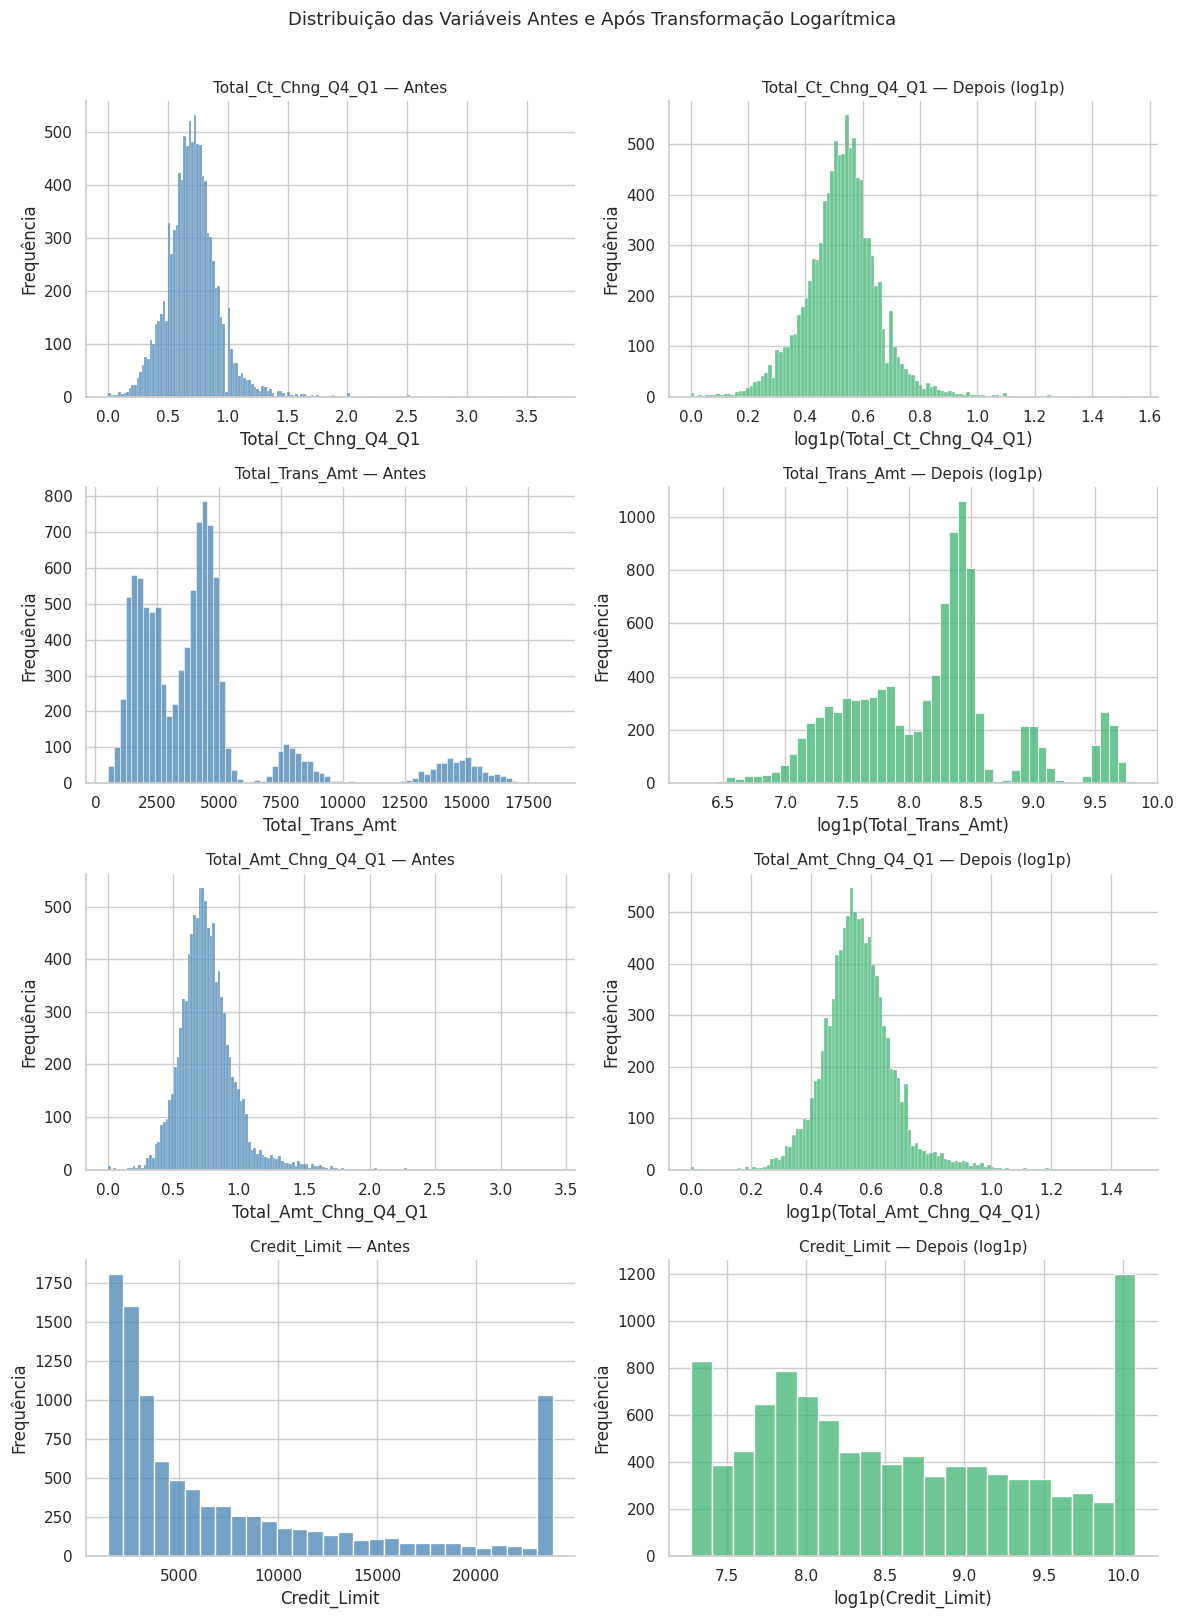


Tabela comparativa de assimetria:
                      Assimetria Antes  Assimetria Depois  Redução (%)
Total_Ct_Chng_Q4_Q1               2.06               0.51         75.3
Total_Trans_Amt                   2.04               0.26         87.3
Total_Amt_Chng_Q4_Q1              1.73               0.65         62.5
Credit_Limit                      1.20               0.32         73.3


In [29]:
# Colunas a excluir da análise de assimetria
colunas_excluir_log = (
    ['Attrition_Flag']                                               # target binário
    + colunas_ohe                                                    # binárias OHE
    + ['Education_Level', 'Income_Category', 'Card_Category']       # ordinais categóricas
    + ['Utilization_Category']                                       # ordinal derivada
    + ['Dependent_count', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
       'Total_Trans_Ct']                                             # discretas com poucos valores únicos
    + colunas_derivadas                                              # criadas em 5.5, sem análise de distribuição prévia no Bloco 4
)

colunas_candidatas_log = [
    c for c in df_encoded.columns if c not in colunas_excluir_log
]

# Calcular skewness antes da transformação
skewness_antes = (
    df_encoded[colunas_candidatas_log]
    .skew()
    .sort_values(ascending=False)
    .round(2)
)

print('Assimetria (skewness) das variáveis contínuas candidatas:')
print(skewness_antes.to_string())

# Selecionar variáveis com assimetria forte
LIMIAR = 1.0
colunas_log = skewness_antes[skewness_antes.abs() > LIMIAR].index.tolist()

print()
print(f'Variáveis com |skewness| > {LIMIAR} (candidatas à transformação):')
print(colunas_log)

# Salvar valores originais para comparação visual
df_antes_log = df_encoded[colunas_log].copy()

# Aplicar np.log1p() nas colunas selecionadas
for col in colunas_log:
    df_encoded[col] = np.log1p(df_encoded[col])

print()
print(f'Transformação log1p aplicada em {len(colunas_log)} variável(is).')

# Comparação de skewness antes vs depois
skewness_depois = df_encoded[colunas_log].skew().round(2)
skewness_red = (
    (df_antes_log.skew().abs() - skewness_depois.abs())
    / df_antes_log.skew().abs() * 100
).round(1)

comparacao_log = pd.DataFrame({
    'Assimetria Antes': df_antes_log.skew().round(2),
    'Assimetria Depois': skewness_depois,
    'Redução (%)': skewness_red,
})

# Visualização: histogramas antes vs depois
sns.set_theme(style='whitegrid')
n_vars = len(colunas_log)
fig, axes = plt.subplots(n_vars, 2, figsize=(12, 4 * n_vars))

# Garantir que axes seja sempre 2D
if n_vars == 1:
    axes = [axes]

for i, col in enumerate(colunas_log):
    # Antes
    sns.histplot(df_antes_log[col], ax=axes[i][0], color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{col} — Antes', fontsize=11)
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frequência')
    sns.despine(ax=axes[i][0])

    # Depois
    sns.histplot(df_encoded[col], ax=axes[i][1], color='mediumseagreen', edgecolor='white')
    axes[i][1].set_title(f'{col} — Depois (log1p)', fontsize=11)
    axes[i][1].set_xlabel(f'log1p({col})')
    axes[i][1].set_ylabel('Frequência')
    sns.despine(ax=axes[i][1])

plt.suptitle('Distribuição das Variáveis Antes e Após Transformação Logarítmica', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print()
print('Tabela comparativa de assimetria:')
print(comparacao_log.to_string())

A transformação foi aplicada em `4` das `8` variáveis contínuas candidatas. As demais `4` apresentaram `|skewness| <= 1,0` e não precisaram de ajuste.

**Variáveis não transformadas:** `Avg_Utilization_Ratio` (`0,718`), `Total_Revolving_Bal` (`-0,149`), `Customer_Age` (`-0,034`) e `Months_on_book` (`-0,107`). Nenhuma delas superou o limiar. Um resultado que merece atenção é o de `Total_Revolving_Bal`: na Seção `4.3` foi observado um pico expressivo em zero (clientes sem saldo rotativo), o que sugeria alta assimetria. No entanto, o skewness calculado foi de apenas `-0,149`, indicando que, após os tratamentos anteriores, a distribuição está próxima do equilíbrio e a transformação não se justifica.

**Variáveis transformadas e resultado:**

| Variável | Skewness antes | Skewness depois | Redução |
|---|---|---|---|
| `Total_Ct_Chng_Q4_Q1` | `2,064` | `0,510` | `75,3%` |
| `Total_Trans_Amt` | `2,041` | `0,263` | `87,1%` |
| `Total_Amt_Chng_Q4_Q1` | `1,732` | `0,648` | `62,6%` |
| `Credit_Limit` | `1,197` | `0,316` | `73,6%` |

A redução foi expressiva em todos os casos, com destaque para `Total_Trans_Amt`, que teve `87,1%` de queda na assimetria. `Credit_Limit` era a única candidata explicitamente identificada na Seção `4.3` como tendo cauda longa à direita: o skewness de `1,197` confirma esse diagnóstico e a transformação reduziu esse valor para `0,316`.

Um ponto de atenção é `Total_Trans_Amt`: a Seção `4.3` identificou essa variável como **bimodal** (dois grupos distintos de uso). A transformação logarítmica não elimina a bimodalidade, apenas comprime a escala. O resultado de `0,263` indica distribuição próxima do simétrico, mas a estrutura de dois picos permanece. Isso não compromete o pré-processamento, mas deve ser lembrado na interpretação dos modelos.

`Total_Ct_Chng_Q4_Q1` e `Total_Amt_Chng_Q4_Q1` medem a variação de transações e de valor entre trimestres, respectivamente. Ambas estavam entre as mais assimétricas do dataset e são diretamente relacionadas à Hipótese `5` (H5: redução de transações de Q1 para Q4 como sinal de churn). A transformação garante que essa relação seja capturada com menos distorção de escala pelos modelos futuros.

## 5.7 Separação features/target e train/test split

Antes de aplicar qualquer transformação de escala (normalização e padronização), é necessário dividir o dataset em **conjunto de treino** e **conjunto de teste**. Essa ordem é fundamental para evitar o chamado **data leakage** (vazamento de dados).

O problema ocorre quando parâmetros de escala, como o mínimo e máximo (normalização) ou a média e o desvio padrão (padronização), são calculados sobre o dataset completo, incluindo os dados de teste. Isso significa que o modelo aprende indiretamente sobre os dados de teste antes mesmo de ser treinado, produzindo uma avaliação de desempenho otimista e irreal.

A estratégia correta é:
1. Realizar o split primeiro
2. Calcular os parâmetros de escala **apenas no conjunto de treino**
3. Aplicar a mesma transformação (com os parâmetros do treino) ao conjunto de teste

Será utilizado `test_size=0.3` (70% treino / 30% teste) e `stratify=y` para garantir que a proporção de churn (`~16%`) seja mantida em ambos os conjuntos.

In [30]:
# Separação de features (X) e target (y)
# X: matriz com todas as variáveis preditoras (exceto o target)
# y: vetor com a variável resposta (0 = cliente ativo, 1 = cancelado)
X = df_encoded.drop('Attrition_Flag', axis=1)
y = df_encoded['Attrition_Flag']

print(f'Features (X): {X.shape[0]} instâncias, {X.shape[1]} colunas')
print(f'\nTarget  (y): {y.shape[0]} instâncias')
print(f'\nColunas de X:')
print(list(X.columns))

Features (X): 10127 instâncias, 26 colunas

Target  (y): 10127 instâncias

Colunas de X:
['Customer_Age', 'Dependent_count', 'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Gender_F', 'Gender_M', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Avg_Transaction_Value', 'Transaction_per_Month', 'Utilization_Category', 'Contacts_per_Inactive_Month']


In [31]:
# Divisão treino/teste
# test_size=0.3  : 30% dos dados reservados para teste
# random_state=42: garante reprodutibilidade (mesma divisão a cada execução)
# stratify=y     : mantém a proporção de churn igual em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Verificação das dimensões e balanceamento do target
print('Dimensões após o split:')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape[0]}  |  y_test: {y_test.shape[0]}')

print('\nProporção do target Attrited por conjunto:')
prop_treino = y_train.mean() * 100
prop_teste  = y_test.mean()  * 100
prop_total  = y.mean()       * 100
print(f'Total:  {prop_total:.2f}%')
print(f'Treino: {prop_treino:.2f}%')
print(f'Teste:  {prop_teste:.2f}%')

Dimensões após o split:
X_train: (7088, 26)  |  X_test: (3039, 26)
y_train: 7088  |  y_test: 3039

Proporção do target Attrited por conjunto:
Total:  16.07%
Treino: 16.07%
Teste:  16.06%


O split dividiu o dataset em `7.088` instâncias para treino (`70%`) e `3.039` para teste (`30%`), totalizando as `10.127` instâncias originais. Cada conjunto mantém as `26` features geradas ao longo do pré-processamento, desde as variáveis originais até as derivadas criadas na Seção 5.5.

O ponto mais importante é a proporção do target em cada subconjunto: `16,07%` no treino e `16,06%` no teste, praticamente idênticos ao total de `16,07%` registrado na Seção 4.1. Isso é resultado direto do parâmetro `stratify=y`: ao estratificar pelo target, garantimos que o desbalanceamento original (cerca de `1` cancelamento para cada `5` clientes ativos) seja preservado em ambas as partes. Sem essa opção, o embaralhamento aleatório poderia concentrar mais casos de churn em um dos conjuntos, distorcendo tanto o treinamento quanto a avaliação do modelo.

A pequena diferença de `0,01%` entre treino e teste é esperada: como o número de instâncias é inteiro, os `1.627` clientes que cancelaram não se dividem em exatamente `70/30`, gerando um arredondamento de `1` instância. Isso não representa problema algum.

A partir daqui, todas as etapas que aprendem parâmetros dos dados, como a normalização (Seção 5.8) e a padronização (Seção 5.9), serão ajustadas exclusivamente sobre `X_train` e depois aplicadas a `X_test`. Isso garante que o conjunto de teste permaneça completamente desconhecido para o modelo até o momento da avaliação.

## 5.8 Normalização

A **normalização Min-Max** reescala cada coluna numérica para o intervalo `[0, 1]`.
A fórmula usada é:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

O `x_min` e o `x_max` são aprendidos **somente a partir dos dados de treino**.
Essa é a regra mais importante desta etapa: o `fit` ocorre apenas no treino,
e o `transform` é aplicado em ambos os conjuntos usando os parâmetros já calculados.

Se calculássemos o mínimo e o máximo incluindo os dados de teste, o modelo
receberia informações que não deveria conhecer antes da avaliação, o que
tornaria os resultados irreais. Por isso, o conjunto de teste deve permanecer
isolado durante todo o pré-processamento.

Algoritmos como KNN, redes neurais e regressão logística com regularização
se beneficiam da normalização porque calculam distâncias ou atribuem pesos
que são sensíveis à escala das variáveis. Uma variável com valores na casa
dos milhares dominaria o cálculo sobre outra com valores entre `0` e `1`,
mesmo que as duas sejam igualmente importantes.

**O que será normalizado:** as `13` colunas numéricas originais contínuas,
como `Customer_Age`, `Credit_Limit` e `Total_Trans_Amt`. As colunas binárias
geradas pelo OHE (`Gender_F`, `Marital_Status_*`), as colunas ordinais
codificadas (`Education_Level`, `Income_Category`, `Card_Category`,
`Utilization_Category`) e as variáveis derivadas contínuas ficam de fora:
já estão em escalas compatíveis ou não se beneficiam do Min-Max.

Serão criadas cópias (`X_train_norm`, `X_test_norm`) para preservar os
conjuntos originais, que serão usados na padronização da seção seguinte.

In [32]:
# Colunas numéricas originais contínuas
# (excluir OHE, ordinais codificadas e derivadas)
colunas_num_orig = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Criar cópias para preservar X_train/X_test originais (serão usados em 5.9)
X_train_norm = X_train.copy()
X_test_norm  = X_test.copy()

# fit apenas no treino — transform em ambos
scaler_norm = MinMaxScaler()
X_train_norm[colunas_num_orig] = scaler_norm.fit_transform(X_train[colunas_num_orig])
X_test_norm[colunas_num_orig]  = scaler_norm.transform(X_test[colunas_num_orig])

# DataFrame de visualização (convenção do projeto)
df_normalized = X_train_norm.copy()

# Verificação: min e max após normalização devem ser 0 e 1 no treino
print(f'Colunas normalizadas: {len(colunas_num_orig)}')
print()
print('Estatísticas das colunas normalizadas (X_train_norm):')
print(X_train_norm[colunas_num_orig].agg(['min', 'max', 'mean']).round(4))
print()
print('\nIntervalo real das colunas no conjunto de teste (X_test_norm):')
print(X_test_norm[colunas_num_orig].agg(['min', 'max']).round(4))

Colunas normalizadas: 13

Estatísticas das colunas normalizadas (X_train_norm):
      Customer_Age  Dependent_count  Months_on_book  Total_Relationship_Count  \
min         0.0000           0.0000          0.0000                     0.000   
max         1.0000           1.0000          1.0000                     1.000   
mean        0.4335           0.4685          0.5348                     0.561   

      Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
min                   0.0000                 0.0000        0.0000   
max                   1.0000                 1.0000        1.0000   
mean                  0.3902                 0.4094        0.4647   

      Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  \
min                0.0000                0.0000           0.0000   
max                1.0000                1.0000           1.0000   
mean               0.4626                0.3721           0.5359   

      Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  Av

A primeira tabela confirma que a normalização foi aplicada corretamente no treino: todas as `13` colunas apresentam `min = 0` e `max = 1` em `X_train_norm`, exatamente como esperado pelo Min-Max Scaler. As médias normalizadas variam entre `0,2771` (`Avg_Utilization_Ratio`) e `0,5359` (`Total_Trans_Amt`), indicando que a maioria das variáveis tem distribuição razoavelmente espalhada dentro do intervalo `[0, 1]`.

A segunda tabela mostra o intervalo real das colunas no conjunto de teste (`X_test_norm`). Como o scaler foi ajustado apenas com os dados de treino, valores do teste que estejam fora do intervalo observado no treino podem resultar em valores ligeiramente abaixo de `0` ou acima de `1`. As colunas com desvios foram: `Total_Ct_Chng_Q4_Q1` (máximo de `1,0203`), `Total_Trans_Amt` (mínimo de `-0,0109` e máximo de `1,0076`), `Avg_Utilization_Ratio` (máximo de `1,004`) e `Total_Amt_Chng_Q4_Q1` (mínimo de `-0,0068`). Além disso, `Customer_Age` atingiu máximo de apenas `0,8936` no teste, indicando que o cliente mais velho do teste é mais jovem que o mais velho do treino. Todos esses desvios são desprezíveis em magnitude e representam o comportamento esperado: forçar o intervalo `[0, 1]` no teste exigiria incluir esses dados no ajuste do scaler, o que configuraria data leakage.